# Predicting Yearly Income using US Census Data

## Higher level context
U.S. Census income data serves multiple purposes, primarily aimed at understanding and
improving the economic well-being of individuals and communities. Some key issues
- Economic Assistance and Program Funding: Different agencies use income data to plan and allocate funding for programs providing economic assistance, such as Medicaid, food assistance, housing support, and job training. These data help determine
eligibility and funding levels for various programs
- Measuring Economic Well-Being: Income data is a critical measure of economic health at individual, household, and community levels. It helps assess poverty status and income inequality, which are essential for policy-making and research
- Community Planning: Local governments use income data to address issues like housing affordability by understanding income distribution within communities. It informs decisions about grants, loans, and other community development initiatives
- Educational Planning: School districts rely on income data to make decisions about funding, staffing, and facilities. It also helps qualify schools for grants under different programs.
- Research and Policy Development: Researchers analyze income trends to study economic growth, disparities, and the impact of policies. The data also supports evaluations of population changes between census years

**References**

https://en.wikipedia.org/wiki/Household_income_in_the_United_States

https://www.census.gov/topics/income-poverty/income.html

https://www.census.gov/acs/www/about/why-we-ask-each-question/income/

https://censusreporter.org/topics/income/


## Problem at hand

**Business Context**:
- Census data informs resource allocation (hospitals, schools) and demographic analysis.
- We want to classify if an individual’s total income is >=50K or <50K, to see how various demographic and work-related factors correlate with higher earnings.

**Goal**:
- Build a robust pipeline to predict high/low income.
- Provide both a technical solution and business insights.



In [25]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association
from config import categorical_columns, numerical_columns, column_index_to_name, TRAIN_PATH, TEST_PATH, CV_SPLITS
pd.set_option('display.max_columns', None)
# Set parameters for plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## EDA

- We must understand how variables are distributed
- Identify potential data quality issues
- Guide decisions about transformations

In [26]:
usecols_list = list(range(24)) + list(range(25, 42)) #ignore weight for prediction task
column_names = column_index_to_name.values()
train_df = pd.read_csv(
    TRAIN_PATH,
    header=None,
    sep=',',
    usecols=usecols_list,
    names=column_names
)

train_df.head(10)

,age,class_of_worker,detailed_industry_recode,detailed_occupation_recode,education,wage_per_hour,unroll_in_edu_inst_last_wk,marital_stat,major_industry_code,major_occupation_code,race,hispanic_origin,sex,member_of_a_labor_union,reason_for_unemployment,full_or_part_time_employment_stat,capital_gains,capital_losses,dividends_from_stocks,tax_filer_stat,region_of_previous_residence,state_of_previous_residence,detailed_household_and_family_stat,detailed_household_summary_in_household,migration_code_change_in_msa,migration_code_change_in_reg,migration_code_move_within_reg,live_in_this_house_1_year_ago,migration_prev_res_in_sunbelt,num_persons_worked_for_employer,family_members_under_18,country_of_birth_father,country_of_birth_mother,country_of_birth_self,citizenship,own_business_or_self_employed,fill_inc_questionnaire_for_veterans_admin,veterans_benefits,weeks_worked_in_year,year,income
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,?,?,?,Not in universe under 1 year old,?,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,?,?,?,Not in universe under 1 year old,?,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
5,48,Private,40,10,Some college but no degree,1200,Not in universe,Married-civilian spouse present,Entertainment,Professional specialty,Amer Indian Aleut or Eskimo,All other,Female,No,Not in universe,Full-time schedules,0,0,0,Joint both under 65,Not in universe,Not in universe,Spouse of householder,Spouse of householder,?,?,?,Not in universe under 1 year old,?,1,Not in universe,Philippines,United-States,United-States,Native- Born in the United States,2,Not in universe,2,52,95,- 50000.
6,42,Private,34,3,Bachelors degree(BA AB BS),0,Not in universe,Married-civilian spouse present,Finance insurance and real estate,Executive admin and managerial,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,5178,0,0,Joint both

In [27]:
# string columns seem to have a preceeding empty space, can mess up further analysis
train_df = train_df.apply(
    lambda col: col.str.strip()
    if col.dtype == "object" and col.apply(isinstance, args=(str,)).all()
    else col
)

In [28]:
train_df.iloc[25]['income']

'- 50000.'

In [29]:
train_df.shape

(199523, 41)

In [30]:
#let's look at the distribution of the target variable
train_df['income'].value_counts(normalize=True) #highly imbalanced dataset only 6% have income over 50k

income
- 50000.    0.937942
50000+.     0.062058
Name: proportion, dtype: float64

In [31]:
train_df.describe()

,age,detailed_industry_recode,detailed_occupation_recode,wage_per_hour,capital_gains,capital_losses,dividends_from_stocks,num_persons_worked_for_employer,own_business_or_self_employed,veterans_benefits,weeks_worked_in_year,year
count,199523.000000,199523.000000,199523.000000,199523.000000,199523.00000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000
mean,34.494199,15.352320,11.306556,55.426908,434.71899,37.313788,197.529533,1.956180,0.175438,1.514833,23.174897,94.499672
std,22.310895,18.067129,14.454204,274.896454,4697.53128,271.896428,1984.163658,2.365126,0.553694,0.851473,24.411488,0.500001
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.000000
25%,15.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,94.000000
50%,33.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,2.000000,8.000000,94.000000
75%,50.000000,33.000000,26.000000,0.000000,0.00000,0.000000,0.000000,4.000000,0.000000,2.000000,52.000000,95.000000
max,90.000000,51.000000,46.000000,9999.000000,99999.00000,4608.000000,99999.000000,6.000000,2.000000,2.000000,52.000000,95.000000


In [32]:
#let's check for null values
train_df.isnull().sum()

age                                          0
class_of_worker                              0
detailed_industry_recode                     0
detailed_occupation_recode                   0
education                                    0
wage_per_hour                                0
unroll_in_edu_inst_last_wk                   0
marital_stat                                 0
major_industry_code                          0
major_occupation_code                        0
race                                         0
hispanic_origin                              0
sex                                          0
member_of_a_labor_union                      0
reason_for_unemployment                      0
full_or_part_time_employment_stat            0
capital_gains                                0
capital_losses                               0
dividends_from_stocks                        0
tax_filer_stat                               0
region_of_previous_residence                 0
state_of_prev

In [33]:
#metadata file mentions 46716 duplicates or conflicting instances, let's confirm
train_df.duplicated().sum() #46627 duplicates. it is unclear how conflicting instances are defined, I don't remove them

46627

In [34]:
#let's drop the duplicated rows
train_df.drop_duplicates(inplace=True)

train_df.shape

(152896, 41)

In [35]:
string_columns = train_df.select_dtypes(include=["object", "string"]).columns

question_mark_counts = {}
for col in categorical_columns:
    question_mark_counts[col] = train_df[col].eq('?').sum()

for column_name, count in question_mark_counts.items():
    print(f"Column '{column_name}': {(count/len(train_df))*100}% rows have '?'")

columns_with_question = [col for col, cnt in question_mark_counts.items() if cnt > 0]
print("\nColumns that contain at least one '?':", columns_with_question)

Column 'class_of_worker': 0.0% rows have '?'
Column 'detailed_industry_recode': 0.0% rows have '?'
Column 'detailed_occupation_recode': 0.0% rows have '?'
Column 'education': 0.0% rows have '?'
Column 'unroll_in_edu_inst_last_wk': 0.0% rows have '?'
Column 'marital_stat': 0.0% rows have '?'
Column 'major_industry_code': 0.0% rows have '?'
Column 'major_occupation_code': 0.0% rows have '?'
Column 'race': 0.0% rows have '?'
Column 'hispanic_origin': 0.0% rows have '?'
Column 'sex': 0.0% rows have '?'
Column 'member_of_a_labor_union': 0.0% rows have '?'
Column 'reason_for_unemployment': 0.0% rows have '?'
Column 'full_or_part_time_employment_stat': 0.0% rows have '?'
Column 'tax_filer_stat': 0.0% rows have '?'
Column 'region_of_previous_residence': 0.0% rows have '?'
Column 'state_of_previous_residence': 0.4565194642109669% rows have '?'
Column 'detailed_household_and_family_stat': 0.0% rows have '?'
Column 'detailed_household_summary_in_household': 0.0% rows have '?'
Column 'migration_co

In [36]:
#columns migration_code_change_in_msa, migration_code_change_in_reg, migration_code_move_within_reg, migration_prev_res_in_sunbelt have approx 50% missing values
#reasonable to expect they won't contribute in the classiciation  task, so let's drop them
drop_columns = ["migration_code_change_in_msa", "migration_code_change_in_reg", "migration_code_move_within_reg", "migration_prev_res_in_sunbelt"]
train_df.drop(columns=drop_columns, inplace=True)
categorical_columns = [column for column in categorical_columns if column not in drop_columns ]
#the remaining columns have only a neglibile amount of "?" values, so let's drop the rows
train_df.replace("?", np.nan, inplace=True)
train_df.dropna(how="any", inplace=True)

train_df.shape
#after deduplication and removal of rows with empty values, we have dropped 55186 rows, or approx. 27.6% of all rows

(144337, 37)

In [37]:
#let's look at the distribution of the target variable after removing data
train_df['income'].value_counts(normalize=True) #still highly imbalanced dataset, 8% have income over 50k

income
- 50000.    0.919342
50000+.     0.080658
Name: proportion, dtype: float64

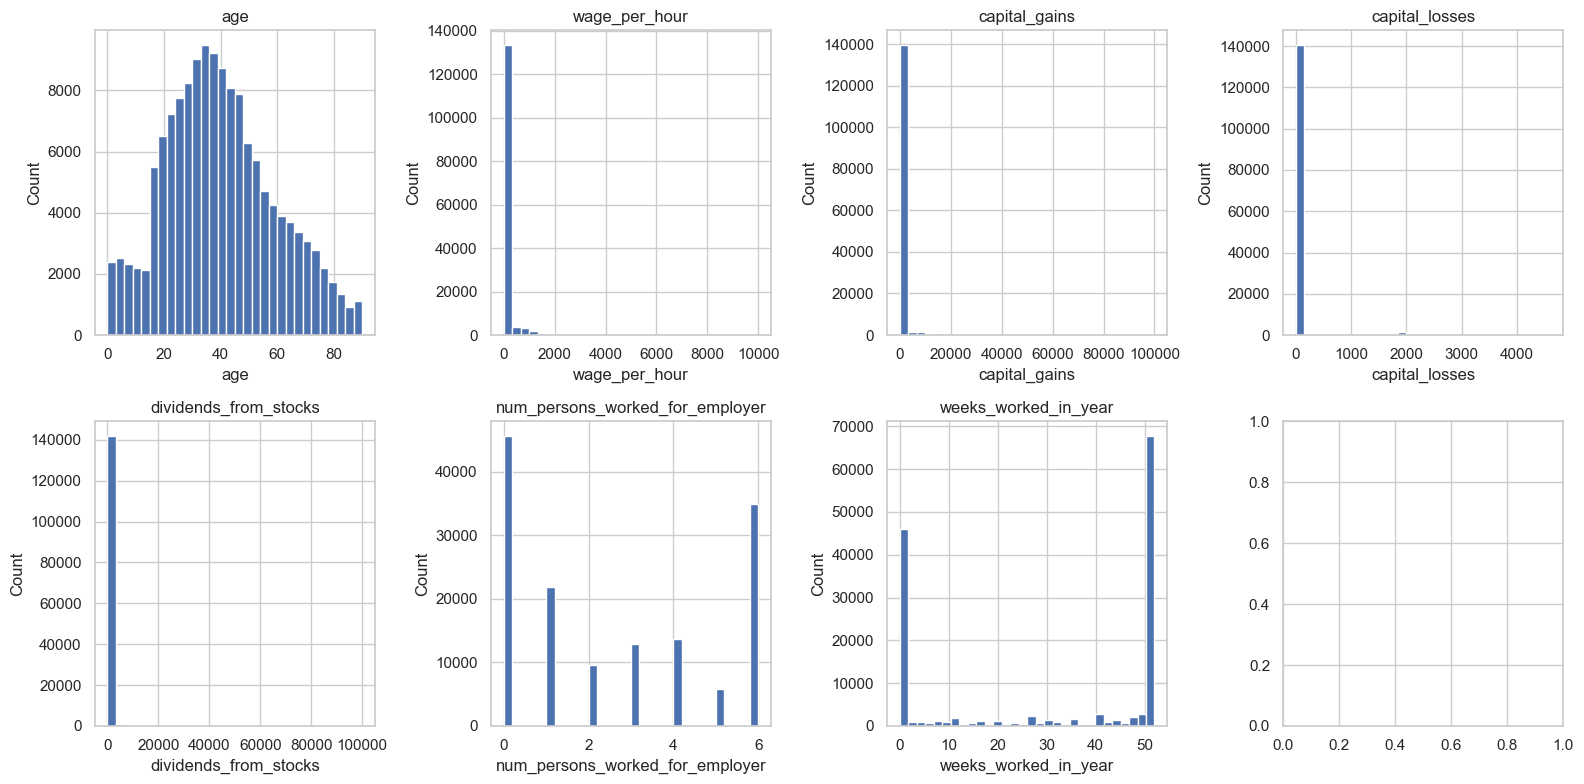

In [38]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))  # example grid: 2 rows x 4 columns
axes = axes.flatten()  # make indexing easier

for i, col in enumerate(numerical_columns):
    axes[i].hist(train_df[col], bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [39]:
print("\nBASIC STATISTICS AND TARGET VARIABLE ANALYSIS")
print("-" * 50)

# Display summary statistics for numerical features
print("\nSummary statistics for numerical features:")
print(train_df[numerical_columns].describe())


BASIC STATISTICS AND TARGET VARIABLE ANALYSIS
--------------------------------------------------

Summary statistics for numerical features:
                 age  wage_per_hour  capital_gains  capital_losses  \
count  144337.000000  144337.000000  144337.000000   144337.000000   
mean       39.470482      73.887035     558.803751       48.694437   
std        19.324706     313.651104    5291.448335      308.931765   
min         0.000000       0.000000       0.000000        0.000000   
25%        26.000000       0.000000       0.000000        0.000000   
50%        38.000000       0.000000       0.000000        0.000000   
75%        52.000000       0.000000       0.000000        0.000000   
max        90.000000    9999.000000   99999.000000     4608.000000   

       dividends_from_stocks  num_persons_worked_for_employer  \
count          144337.000000                    144337.000000   
mean              252.077063                         2.582096   
std              2249.421872    


Income level distribution:
income
- 50000.    132695
50000+.      11642
Name: count, dtype: int64
Percentage of high income (>50K): 8.07%
Percentage of low income (<=50K): 91.93%


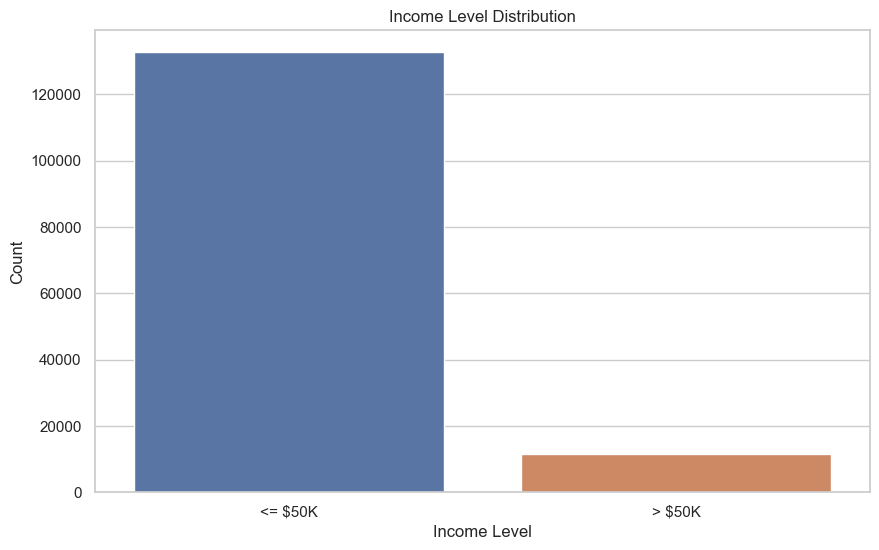

In [40]:
# Count of each income level
print("\nIncome level distribution:")
income_counts = train_df['income'].value_counts()
print(income_counts)
print(f"Percentage of high income (>50K): {100 * income_counts['50000+.'] / len(train_df):.2f}%")
print(f"Percentage of low income (<=50K): {100 * income_counts['- 50000.'] / len(train_df):.2f}%")

# Plot income distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='income', data=train_df)
plt.title('Income Level Distribution')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.xticks([0, 1], ['<= $50K', '> $50K'])
plt.show()


UNIVARIATE ANALYSIS - NUMERICAL FEATURES
--------------------------------------------------

Analyzing age:
count    144337.000000
mean         39.470482
std          19.324706
min           0.000000
25%          26.000000
50%          38.000000
75%          52.000000
max          90.000000
Name: age, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


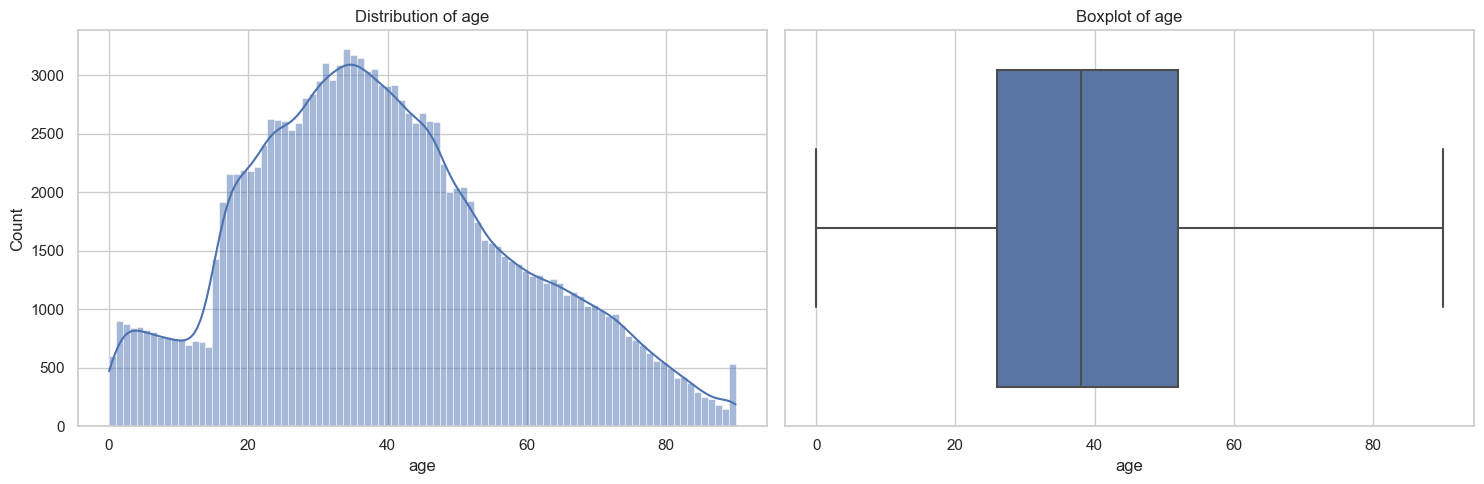


Analyzing wage_per_hour:
count    144337.000000
mean         73.887035
std         313.651104
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        9999.000000
Name: wage_per_hour, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


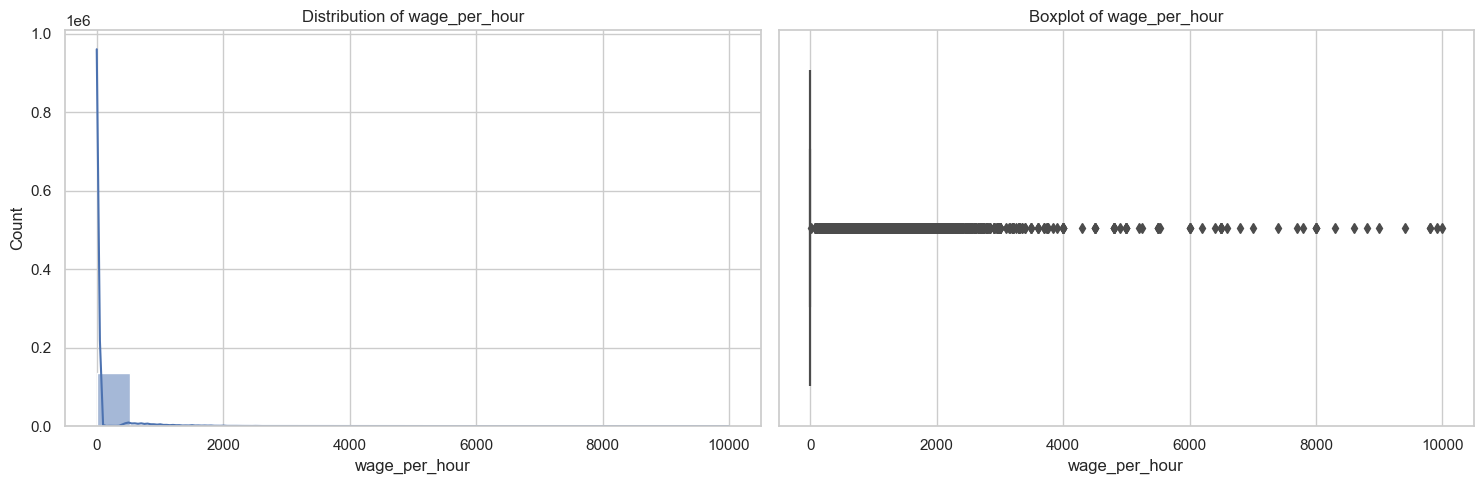


Analyzing capital_gains:
count    144337.000000
mean        558.803751
std        5291.448335
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       99999.000000
Name: capital_gains, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


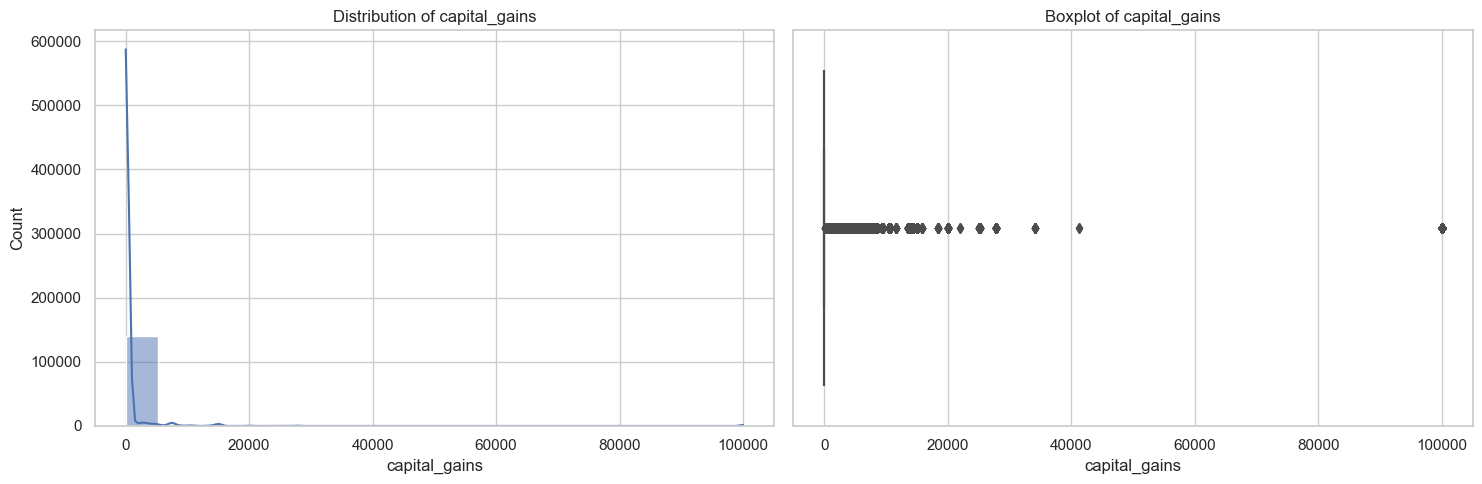


Analyzing capital_losses:
count    144337.000000
mean         48.694437
std         308.931765
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        4608.000000
Name: capital_losses, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


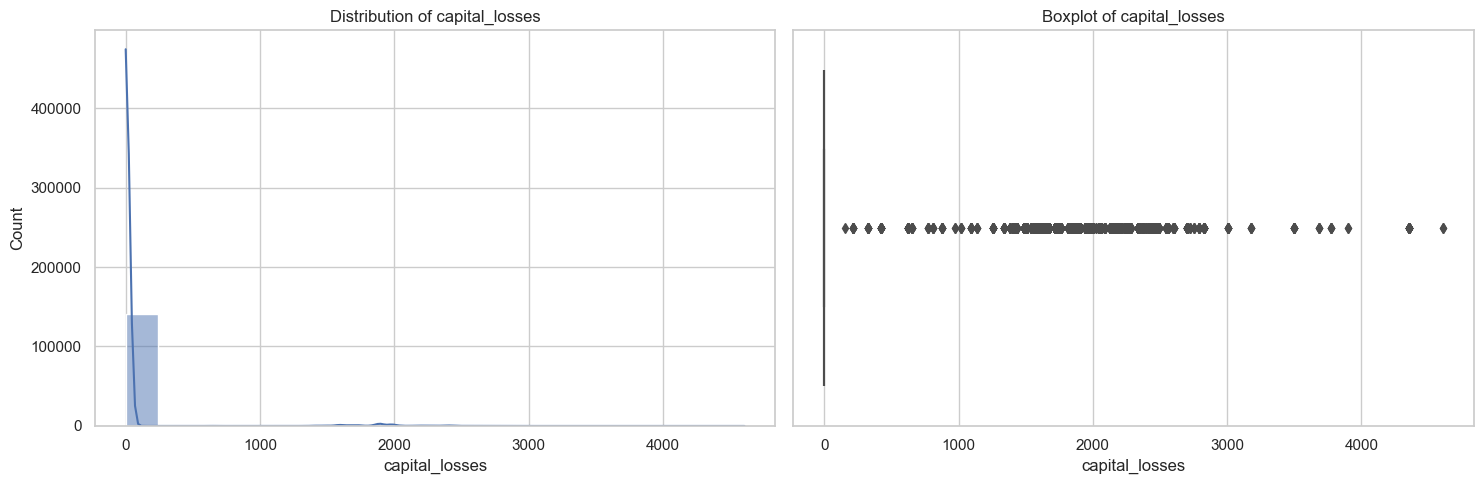


Analyzing dividends_from_stocks:
count    144337.000000
mean        252.077063
std        2249.421872
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       99999.000000
Name: dividends_from_stocks, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


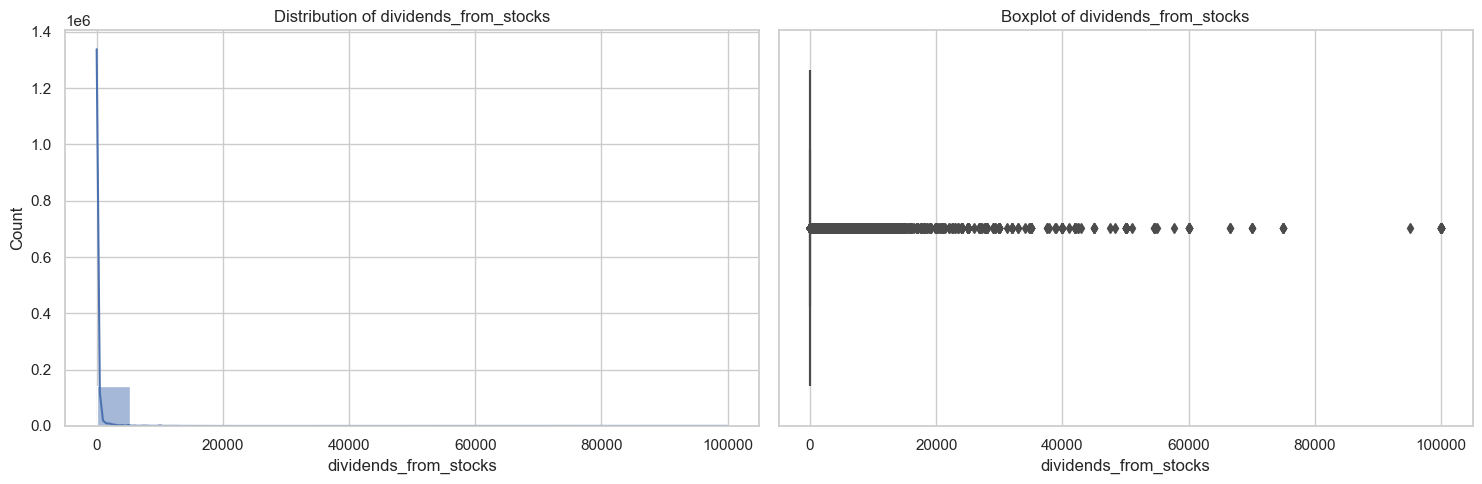


Analyzing num_persons_worked_for_employer:
count    144337.000000
mean          2.582096
std           2.402600
min           0.000000
25%           0.000000
50%           2.000000
75%           5.000000
max           6.000000
Name: num_persons_worked_for_employer, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


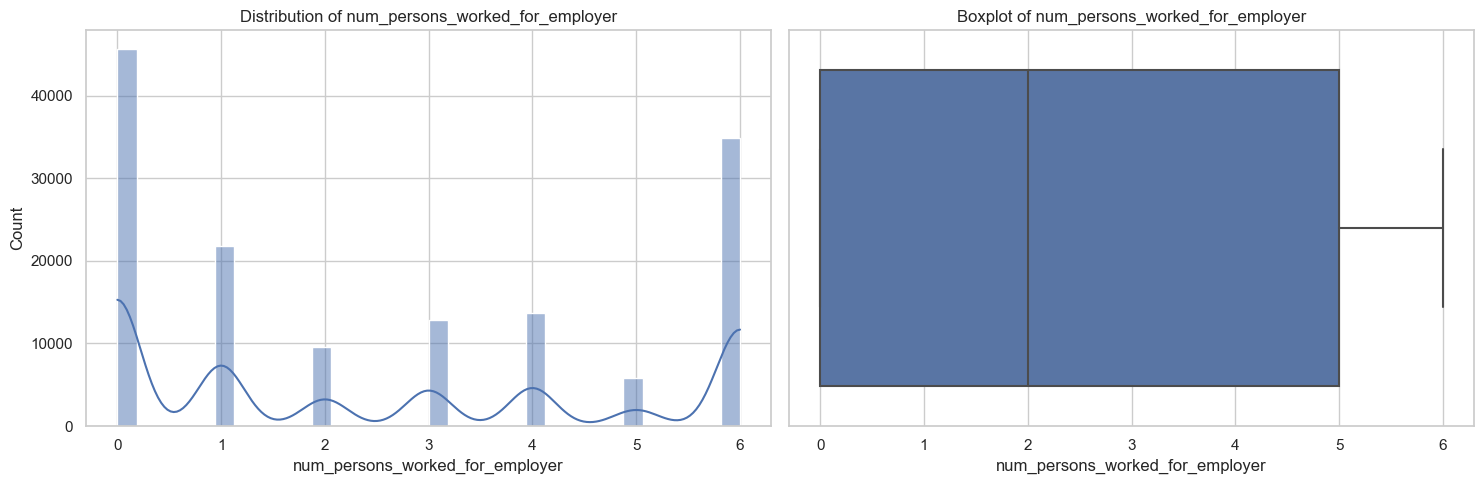


Analyzing weeks_worked_in_year:
count    144337.000000
mean         30.548356
std          23.667065
min           0.000000
25%           0.000000
50%          48.000000
75%          52.000000
max          52.000000
Name: weeks_worked_in_year, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


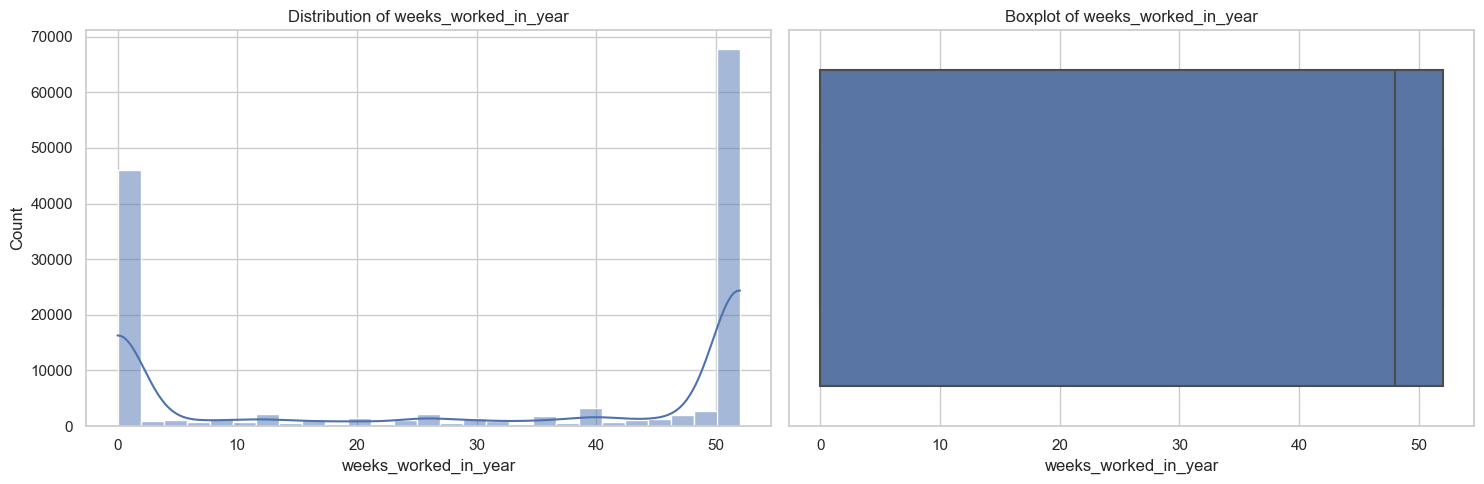

In [41]:
print("\nUNIVARIATE ANALYSIS - NUMERICAL FEATURES")
print("-" * 50)


for column in numerical_columns:
    print(f"\nAnalyzing {column}:")
    print(train_df[column].describe())
    
    plt.figure(figsize=(15, 5))
    
    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(train_df[column], kde=True)
    plt.title(f'Distribution of {column}')
    
    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=train_df[column])
    plt.title(f'Boxplot of {column}')
    
    plt.tight_layout()
    plt.show()


#### Insights of univariate analysis of numerical features

1. `age`:
- From late teens to 80+
- Age is distributed heavily toward working-age adults (20s–50s)
- A small tail extends into older ages
- **Insight**: Distribution concentrated in working-age adults. This matters for modeling because older individuals often have higher stable incomes, but it depends on other employment factors too

2. `wage_per_hour`:
- Most records show 0 (probably salaried workers)
- Highly zero-inflated distribution, with a smaller subset of individuals having positive values (e.g., typical hourly wages might range from a few dollars per hour to tens of dollars; outliers can appear if specialized roles or data entry issues exist).
- **Insight**: Because of the large proportion of zeros, any standard summary (e.g., mean vs. median) can be misleading. This feature needs to be treated carefully:binary feature (paid hourly vs. not) or applying transformations

3. `capital_gains`:
- Often 0 for the majority, with some individuals having positive gains (and a small fraction having very large gains)
- Heavy right-skew (small percentage may have large values)
- **Insight**: A small subset with large capital gains can strongly indicate higher overall wealth and potential for “50K+” income. Because of the strong skew, a log transform (on nonzero values) could be used

4. `capital_losses`:
- Similar to `capital_gains` (usually 0 for most, with occasional positive values). Also heavily right-skewed
- **Insight**: The presence (or size) of capital losses can be indicative of more active or sophisticated investments—again often correlated with higher overall income, albeit in a more nuanced way.

5. `dividends_from_stocks`:
- Similar story to capital gains—0 for most, with some moderate to very large values
- **Insight**: Another wealth indicator that may separate the higher-income bracket from the bulk of the population

6. `num_persons_worked_for_employer`:
- Often a small integer. According to the metadata, possible values might be from 0 up to a certain maximum (7 distinct values are typical in the original dataset)
- **Insight**: Univariate analysis doesn't reveal much, need to look further

7. `weeks_worked_in_year`:
- Often bimodal or skewed, with a cluster around 0 (those unemployed or not in the labor force) and a larger cluster near 52 (those working year-round)
- Many individuals who are employed full-time will show 48+ weeks
- **Insight**: Longer work duration is typically correlated with higher yearly income. This feature should be predictive for classification






UNIVARIATE ANALYSIS - CATEGORICAL FEATURES
--------------------------------------------------


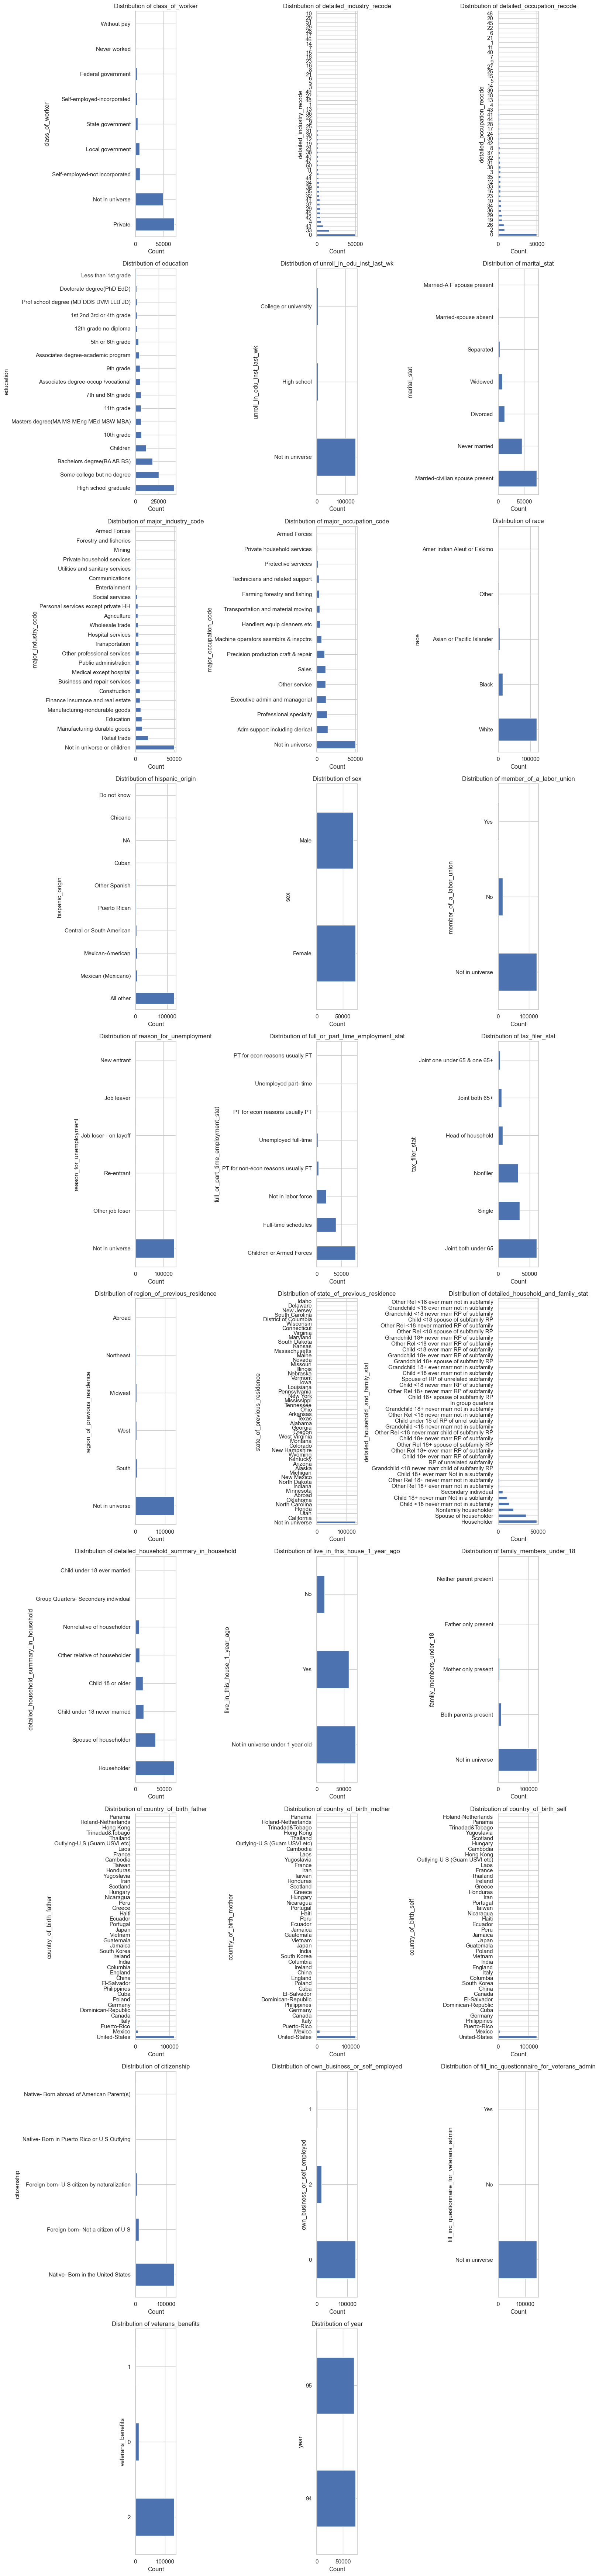

In [42]:
print("\nUNIVARIATE ANALYSIS - CATEGORICAL FEATURES")
print("-" * 50)

num_plots = len(categorical_columns)
cols = 3
rows = math.ceil(num_plots / cols)


fig, axes = plt.subplots(rows, cols, figsize=(15, 7 * rows))

axes = axes.flatten()
for i, column in enumerate(categorical_columns):
    value_counts = train_df[column].value_counts()
    
    
    value_counts.plot(kind='barh', ax=axes[i])
    axes[i].set_title(f'Distribution of {column}')
    axes[i].set_xlabel('Count')


for j in range(i + 1, len(axes)):
    axes[j].axis('off')


plt.tight_layout()
plt.show()

#### Insights of univariate analysis of categorical features

1. `Class of Worker`:
- Dominant Category: Often Private is the most common worker classification (i.e., private sector employment)
- Smaller Categories: Federal government, State government, and Local government appear in smaller proportions. Never worked or Without pay tend to be very small segments
- Not in Universe: Some records show “Not in universe,” which means the question didn’t apply (e.g., certain age groups or those who have never been in the labor force).
- **Insight**: Private vs. others can be very informative.

2. `Education`:
- Large Categories: High school graduate, Some college but no degree, and Bachelors degree typically appear most frequently
- Smaller Categories: Doctorate degree, Prof school degree, Less than 1st grade are relatively rare
- Children: Sometimes labeled as Children or Not in universe for minors not in an education track
- **Insight**: Education will probably be strongly correlated with income. Low-frequency categories (e.g., doctorate) which might show distinct high-income patterns have sparse data.

3. `Marital Status`:
- Common Groups: Never married and Married-civilian spouse present typically dominate
- Less Frequent: Married-spouse absent, Widowed, Divorced, Separated
- **Insight**: Marital status can reflect household structure (e.g., dual incomes vs. single). Combining less frequent categories may help if some are too small for stable modeling signals.

4. `Major Industry Code / Major Occupation Code`:
- Not in Universe or Children: A notable percentage can be “Not in universe” if individuals are not in the workforce (e.g., retirees, children)
- Most Common Industries: Manufacturing, Retail trade, Business and repair services, appear very often
- **Insight**: Industry/occupation likelu provide strong signals about earning potential, but the distributions often have a “long tail” of smaller industries/occupations. Grouping or reducing dimensionality could help

5. `Race and Hispanic Origin`:
- Race: Typically, White is the majority, followed by Black, with other categories (e.g., Asian or Pacific Islander, Amer Indian) in smaller proportions
- Hispanic Origin: Mexican, Puerto Rican, etc. can appear, but there may be many labeled All other or Do not know
- **Insight**: Heavily imbalanced distributions. Socioeconomic patterns can vary by race/hispanic origin, so these can be predictive

6. `Sex`:
- Common Split: Generally equal split, with slightly more males
- **Insight**: Likely an important feature for modeling. Straightforward binary encoding will probably be enough.

7. `Region / State of Previous Residence`:
- Not in Universe: Large fraction if the person did not move or if the question is irrelevant
- **Insight**: Not in universe can overshadow other categories. Potentially merge less frequent states into an “other” category or use region-level groupings

8. `Other Categorical Columns`(tax filer status, citizenship, etc.):
- **Insight**: Many columns have Not in universe, which can signal individuals outside a certain question’s scope. For modeling, let's start by merging low-frequency categories or one-hot encode carefully to avoid large, sparse matrices

**General Observations**:
- “Not in Universe”: Shows up in multiple columns. In some cases, it’s a large fraction, effectively a separate “category” indicating the question did not apply (children, retirees, etc.)
- Highly Imbalanced Distributions: Several features have one or two dominant categories, with the rest split among many minor categories
- Potential Dimensionality Challenges: Columns like `detailed_industry_recode` or `detailed_household_and_family_stat` can have dozens of possible values, each with relatively few records
- Modeling Approaches:
    - Encoding: One-hot encoding can explode dimensionality; target encoding or frequency-based grouping might be more scalable.
    - Combining Categories: Grouping similar or rare categories can help reduce sparse “dummy” features.
    - Interactions: Interactions (e.g., industry × occupation × sex) may be informative but also drastically increase feature space.




BIVARIATE ANALYSIS - NUMERICAL FEATURES VS TARGET
--------------------------------------------------

Analyzing age vs. income_level:
             count       mean        std   min   25%   50%   75%   max
income                                                                
- 50000.  132695.0  38.893131  19.753626   0.0  24.0  37.0  52.0  90.0
50000+.    11642.0  46.051108  11.632138  16.0  38.0  45.0  53.0  90.0


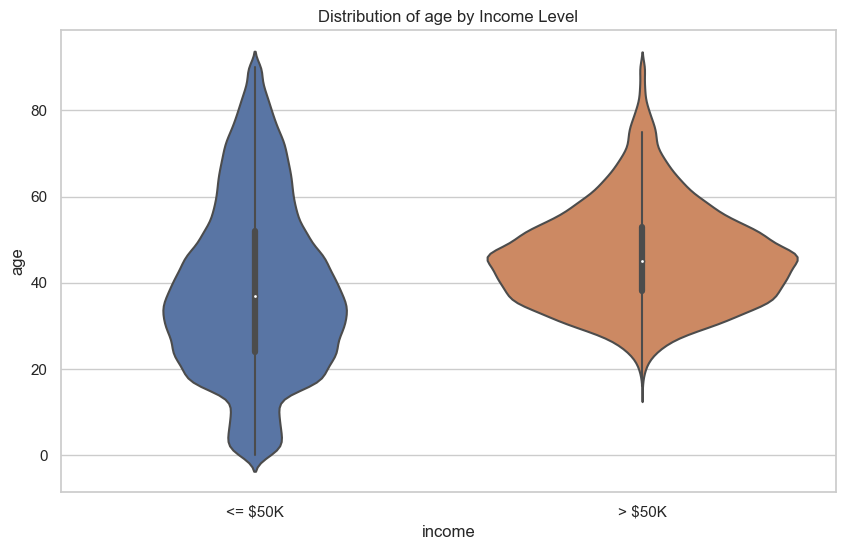


Analyzing wage_per_hour vs. income_level:
             count       mean         std  min  25%  50%  75%     max
income                                                               
- 50000.  132695.0  73.092701  300.907598  0.0  0.0  0.0  0.0  9916.0
50000+.    11642.0  82.940818  433.091088  0.0  0.0  0.0  0.0  9999.0


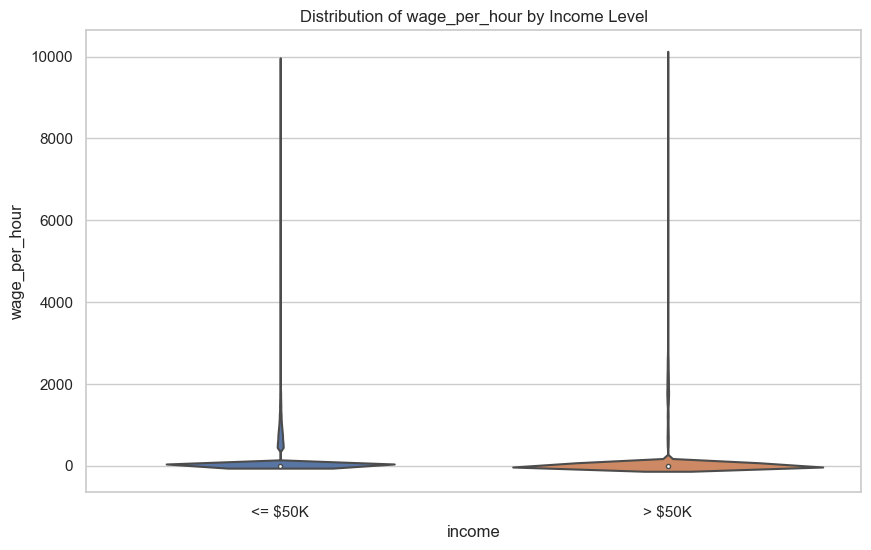


Analyzing capital_gains vs. income_level:
             count         mean           std  min  25%  50%  75%      max
income                                                                    
- 50000.  132695.0   189.993609   2049.996822  0.0  0.0  0.0  0.0  99999.0
50000+.    11642.0  4762.485398  16734.293713  0.0  0.0  0.0  0.0  99999.0


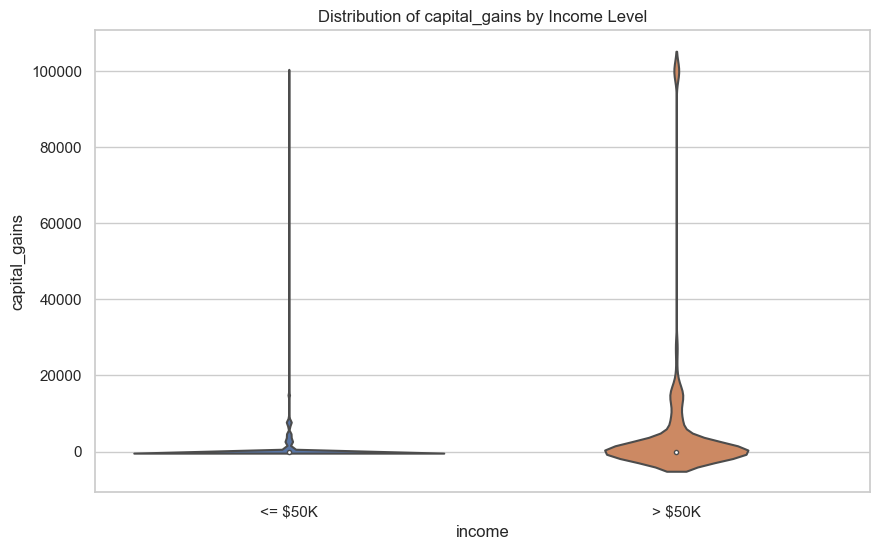


Analyzing capital_losses vs. income_level:
             count        mean         std  min  25%  50%  75%     max
income                                                                
- 50000.  132695.0   36.033000  263.645852  0.0  0.0  0.0  0.0  4608.0
50000+.    11642.0  193.008933  606.926617  0.0  0.0  0.0  0.0  3683.0


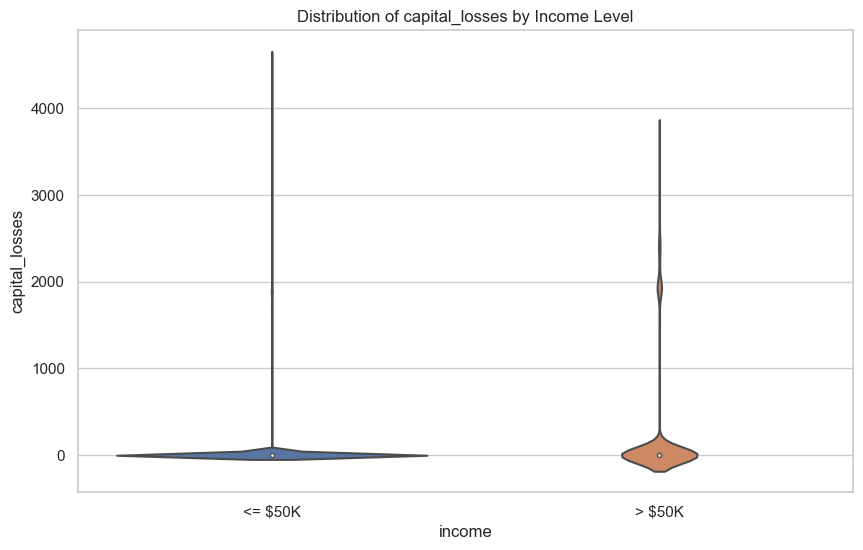


Analyzing dividends_from_stocks vs. income_level:
             count         mean          std  min  25%  50%    75%      max
income                                                                     
- 50000.  132695.0   138.913441  1027.783702  0.0  0.0  0.0    0.0  39000.0
50000+.    11642.0  1541.911012  6991.889083  0.0  0.0  0.0  350.0  99999.0


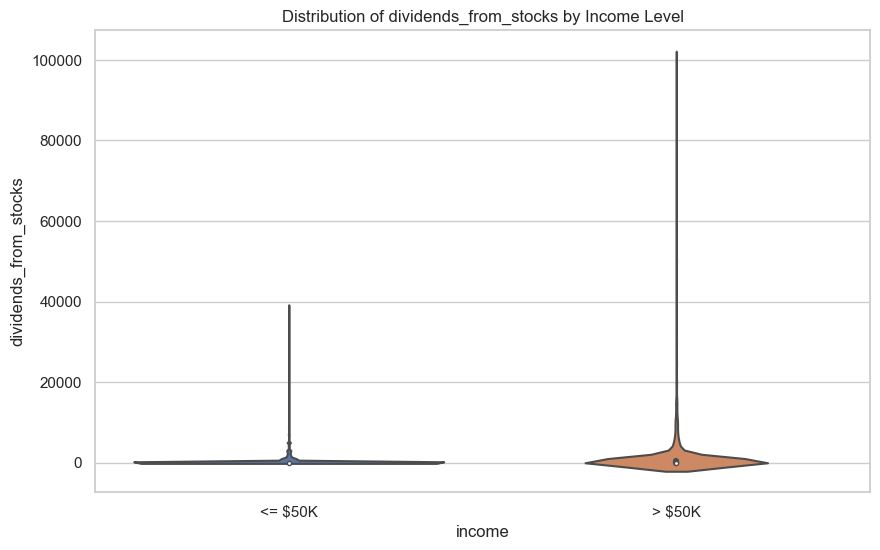


Analyzing num_persons_worked_for_employer vs. income_level:
             count      mean       std  min  25%  50%  75%  max
income                                                         
- 50000.  132695.0  2.455239  2.385206  0.0  0.0  2.0  5.0  6.0
50000+.    11642.0  4.028002  2.109022  0.0  2.0  5.0  6.0  6.0


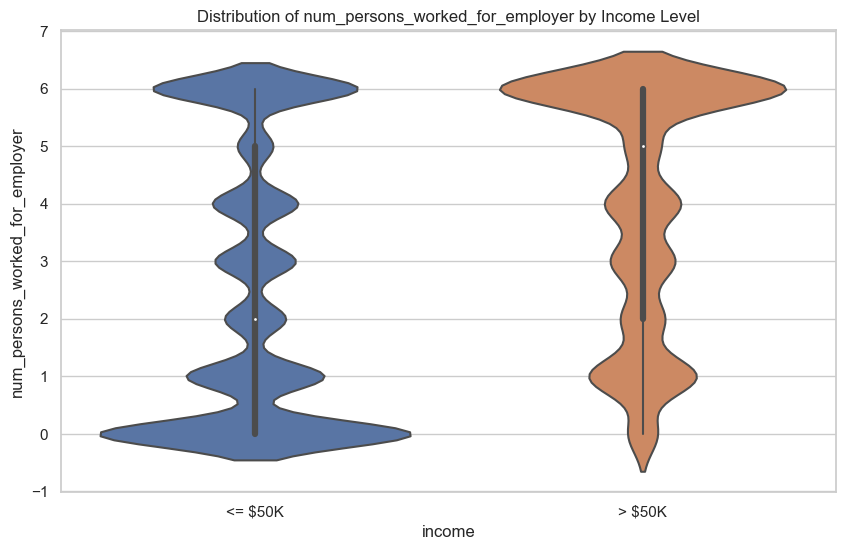


Analyzing weeks_worked_in_year vs. income_level:
             count       mean        std  min   25%   50%   75%   max
income                                                               
- 50000.  132695.0  28.997475  23.808718  0.0   0.0  40.0  52.0  52.0
50000+.    11642.0  48.225219  11.983501  0.0  52.0  52.0  52.0  52.0


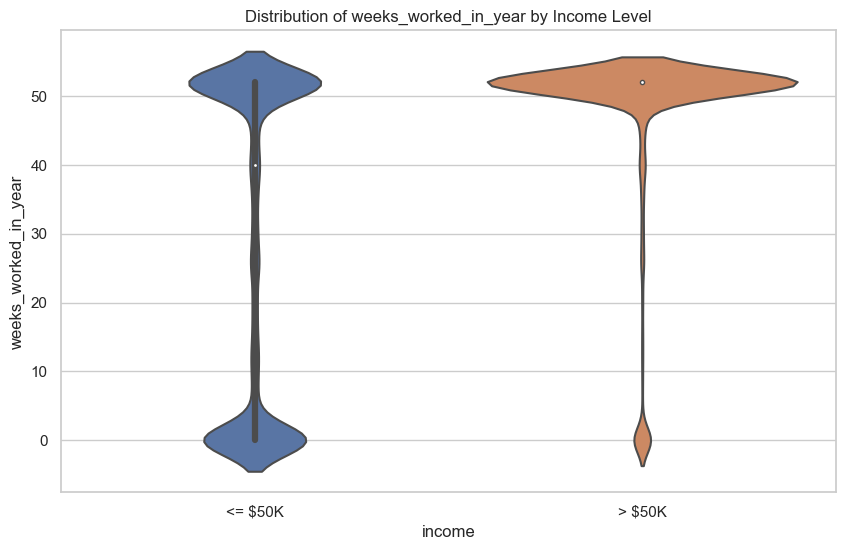

In [43]:
print("\nBIVARIATE ANALYSIS - NUMERICAL FEATURES VS TARGET")
print("-" * 50)

for column in numerical_columns:
    print(f"\nAnalyzing {column} vs. income_level:")
    
    # Group statistics
    print(train_df.groupby('income')[column].describe())
    
    # Violin plot to see distribution shapes
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='income', y=column, data=train_df)
    plt.title(f'Distribution of {column} by Income Level')
    plt.xticks([0, 1], ['<= $50K', '> $50K'])
    plt.show()


CORRELATION ANALYSIS
--------------------------------------------------

Correlation with high income:
high_income                        1.000000
capital_gains                      0.235312
weeks_worked_in_year               0.221232
num_persons_worked_for_employer    0.178257
dividends_from_stocks              0.169844
capital_losses                     0.138368
age                                0.100865
wage_per_hour                      0.008550
Name: high_income, dtype: float64


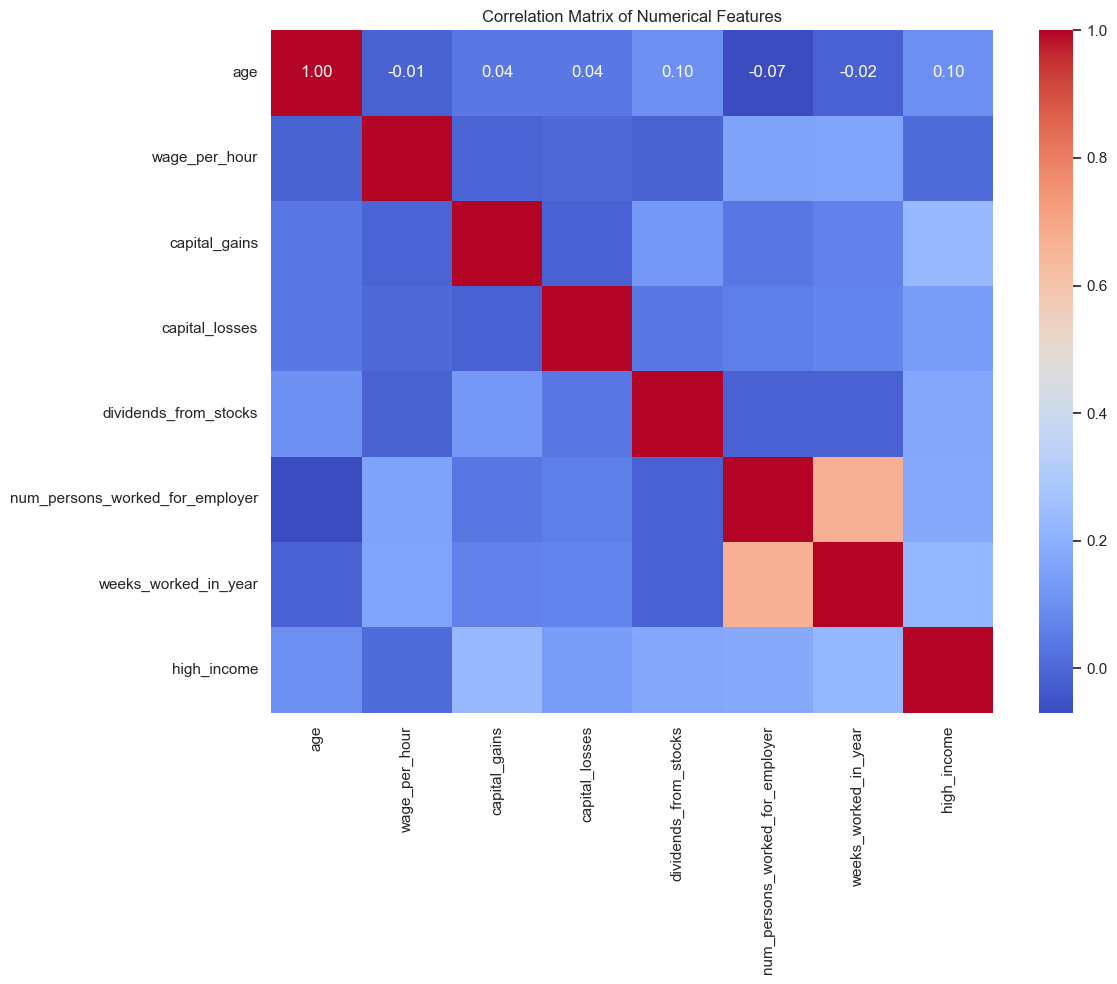

In [44]:
print("\nCORRELATION ANALYSIS")
print("-" * 50)

# Create binary target for correlation
train_df['high_income'] = (train_df['income'] == '50000+.').astype(int)

# Create correlation matrix for numerical features
corr_df = train_df[numerical_columns + ['high_income']].copy()
correlation_matrix = corr_df.corr()

print("\nCorrelation with high income:")
print(correlation_matrix['high_income'].sort_values(ascending=False))

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

#### Insights from bivariate analysis (feature vs target) of numerical features

1. `age` vs. `income`:
- Higher Mean Age for >=50K: Individuals who earn >=50K tend to be older on average than those who earn <50K, but there is overlap
- Broad Range: Younger individuals (<25) are primarily in the <50K group, though a small minority may still appear in >=50K
- Outliers: Some older individuals still appear in <50K, likely due to partial retirement or other factors
- Mild Positive Correlation: Age shows a smaller correlation—older workers are somewhat more likely to have higher earnings, but the relationship is far from deterministic

2. `wage_per_hour` vs. `income`:
- Mostly Zero: A large proportion of both classes have wage_per_hour = 0 (common for salaried workers)
- Nonzero Means: Among those with nonzero wages, the median hourly wage is often higher for >=50K. However, many in the <50K group also have moderate hourly wages
- Sparse High Values: Some individuals with high hourly wages appear in the ≥50K group, although that group is relatively small

3. `capital_gains` vs. `income`:
- Zero for Most in <50K: The majority of <50K earners have zero capital gains
- Nonzero Gains: Even in the >=50K group, many have zero gains, but those with nonzero—and especially large—gains are more frequently >=50K
- Heavy Right Skew: Outliers with very large gains almost always fall in the >=50K bucket
- Highest Positive Correlation: Of all the numeric features, capital_gains has the strongest (though still moderate) linear correlation with high income. Individuals reporting non-zero (especially large) capital gains are much more likely to earn ≥50K

4. `capital_losses` vs. `income`:
- Similar to Capital Gains: The majority of both classes show zero losses
- Presence of Losses: Nonzero capital losses are more likely among >=50K earners (reflecting more active investing), though still a small fraction overall

5. `dividends_from_stocks` vs. `income`:
- Zero Inflation: Most <50K earners have zero dividends. Among >=50K earners, many also have zero, but a significant subset has meaningful dividends
- Higher Dividend Levels: The few who receive large dividends are almost exclusively in >=50K
- Similar to capital gains, individuals receiving dividends from stocks show a higher propensity for high income

6. `num_persons_worked_for_employer` vs. `income`:
- Slightly Higher for >=50K: Individuals with higher values (i.e., more employees) can appear more frequently in >=50K (moderate positive correlation), reflecting managerial or self-employed situations,
- Overlap: Plenty of <50K earners also register low or moderate values, so the separation isn’t huge

7. `weeks_worked_in_year` vs. `income`:
- Higher Typical Weeks for >=50K: The median weeks worked (e.g., 50–52) is noticeably higher for >=50K than for <50K (often 30–40 or even 0 for some).
- Overlap: Despite moderate correlation, some full-time or high-week individuals may still fall below 50K, and others with fewer weeks may rely on investment income. Thus, the correlation, while meaningful, is not extremely high




BIVARIATE ANALYSIS - CATEGORICAL FEATURES VS TARGET
--------------------------------------------------


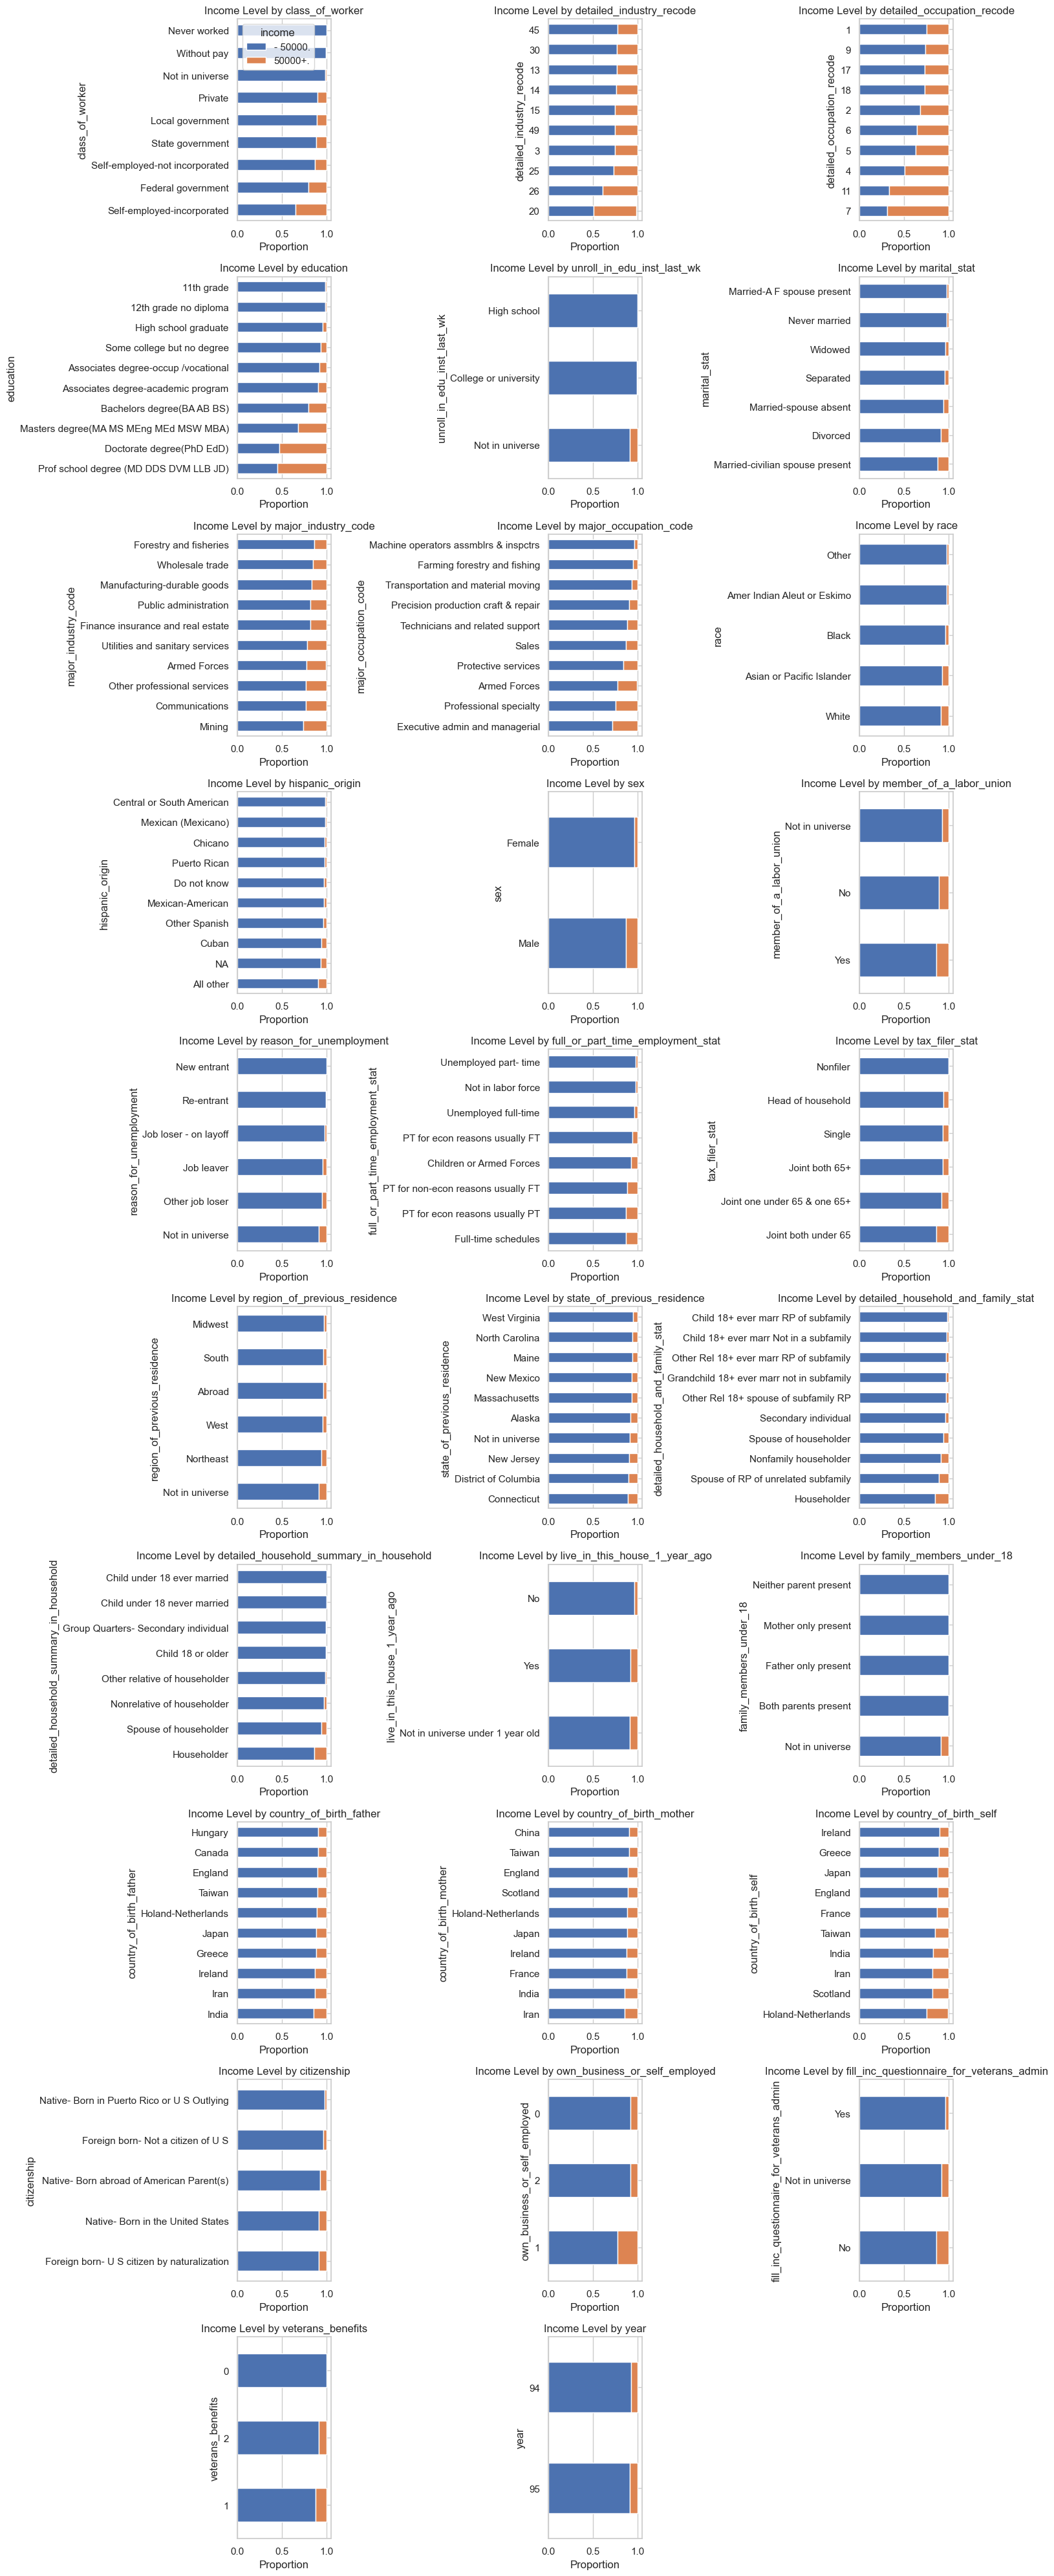

In [45]:
print("\nBIVARIATE ANALYSIS - CATEGORICAL FEATURES VS TARGET")
print("-" * 50)

# Calculate the number of categorical columns and rows needed
n_cols = len(categorical_columns)
n_rows = math.ceil(n_cols / 3)  # 3 subplots per row, round up


fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(15, 4 * n_rows))


axes = axes.flatten()
for i, column in enumerate(categorical_columns):
    # Create crosstab
    ct = pd.crosstab(train_df[column], train_df['income'])

    # Calculate proportion of high income for each category
    ct['prop_high_income'] = ct['50000+.'] / (ct['50000+.'] + ct['- 50000.'])

    # Keep top 10 categories by proportion of high income
    ct = ct.sort_values('prop_high_income', ascending=False).head(10)

    
    props = ct.div(ct.sum(axis=1), axis=0).drop('prop_high_income', axis=1)

    
    ax = axes[i]
    props.plot(kind='barh', stacked=True, ax=ax, legend=(i == 0))
    ax.set_title(f'Income Level by {column}')
    ax.set_xlabel('Proportion')
    ax.set_ylabel(column)


for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [46]:
#references:
#https://stackoverflow.com/questions/20892799/using-pandas-calculate-cram%C3%A9rs-coefficient-matrix
def cramers_v(cat_series, target_series):
    """
    Computes Cramér's V statistic for categorical-categorical association.
    cat_series: pd.Series of a categorical feature
    target_series: pd.Series of the binary target (categorical)
    """
    # Build a frequency table (contingency table)
    confusion_matrix = pd.crosstab(cat_series, target_series)

    # Perform Chi-squared test
    chi2, p, dof, expected = chi2_contingency(confusion_matrix)

    # Number of observations
    n = confusion_matrix.sum().sum()

    # Cramér's V calculation
    # v = sqrt( chi2 / (n * (k - 1)) )
    # where k = min(#rows, #columns)
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k, r) - 1)))

# Create binary target for correlation
train_df['high_income'] = (train_df['income'] == '50000+.').astype(int)
results = {}
for col in categorical_columns:
    cv = cramers_v(train_df[col], train_df['high_income'])  # Assuming 'income' is your binary label
    results[col] = cv

# Convert to a DataFrame for sorting and display
corr_df = pd.DataFrame.from_dict(results, orient='index', columns=['cramers_v'])
corr_df.sort_values(by='cramers_v', ascending=False, inplace=True)

print("Cramér's V for Categorical Features vs. High Income (Descending):")
corr_df


Cramér's V for Categorical Features vs. High Income (Descending):


,cramers_v
detailed_occupation_recode,0.416478
education,0.370778
major_occupation_code,0.338637
detailed_industry_recode,0.258457
major_industry_code,0.240184
class_of_worker,0.220042
detailed_household_and_family_stat,0.211478
detailed_household_summary_in_household,0.198302
tax_filer_stat,0.195506
sex,0.177306


#### Insights from bivariate analysis (feature vs target) for categorical columns

1. `Class of worker`:
- Self-employed (incorporated) can exhibit a higher share of >=50K, reflecting business ownership
- Government workers may have moderate proportions of >=50K
- Without pay / Never worked is almost entirely <50K

2. `Education`:
- Education level is classically a key determinant of earning potential. Higher degrees (Bachelors, Masters, Doctorate) correlate with substantially higher income, whereas high-school or lower correlate with <50K
- The relatively high Cramér’s V here aligns with the typical expectation that education is one of the top predictors

3. ` Marital Status`:
- Married individuals (especially with spouse present) often show higher earnings than never-married or divorced individuals, but there is notable overlap

4.  `Major Industry / Major Occupation Code`:
- Professional services, Finance/Insurance/Real Estate, and Public Administration can have higher shares of >=50K
- Retail, Personal services, and Agriculture tend to skew <50K
- Not in Universe or Children categories typically have a very low share of >=50K, as these individuals are often not active in the labor force
- Also reflected in the correlaction scores

5. `Race and Hispanic Origin`:
- Race: Typically, White might have a moderately higher share of ≥50K compared to other race categories
- For both of these demographic categories, the correlation is very low, nevertheless they require careful interpretation and handling to avoid biases

6. `Sex`:
- Male vs. Female: Males often exhibit a higher fraction of >=50K, reflecting well-known gender pay gaps
- Overlap: Many women also appear in the >=50K category, and the gap might be smaller or larger depending on the rest of the variables (education, occupation, etc.)
- Sex alone is rarely as strong as occupation/education, but it is still correlated with the target.

7. ` Region/State of Previous Residence`:
- Some states or regions with higher living costs or job markets (e.g., Northeast, West Coast) may show a slightly higher share of >=50K earners

8. `Other Categorical Columns`:
- Tax Filer Status: Joint filers often correlate with higher incomes than Single or Head of household filers
- Family Members Under 18: Both parents present might correlate with more stable/higher household incomes, while Mother only present or Father only present may see lower
- Citizenship: Foreign born‐Not a citizen can show a lower proportion of ≥50K than Native‐Born in the US, but this is context-dependent
- Live in This House 1 Year Ago: Yes or No has very low correlation with income

**Common Themes**
- Strong Predictors: Education, marital status, occupation code, and class_of_worker typically show the most pronounced differences in the share of >=50K
- “Not in Universe”: Many columns (e.g., reason_for_unemployment, class_of_worker, major_occupation_code) have large segments labeled “Not in universe,” typically leading to a low share of >=50K, as these individuals are often not in the active labor force
- Long-Tail Categories: Certain columns (e.g., industry recode, household/family stat) have dozens of subcategories. Often, a small cluster of categories account for the bulk of records, while many rare categories can have unreliable or highly varied proportions
- Imbalanced Classes: Because ≥50K is the minority class (per the metadata, ~6–7%), some categories might appear to have “low” shares of >=50K just because of the overall baseline

In [47]:
train_df

,age,class_of_worker,detailed_industry_recode,detailed_occupation_recode,education,wage_per_hour,unroll_in_edu_inst_last_wk,marital_stat,major_industry_code,major_occupation_code,race,hispanic_origin,sex,member_of_a_labor_union,reason_for_unemployment,full_or_part_time_employment_stat,capital_gains,capital_losses,dividends_from_stocks,tax_filer_stat,region_of_previous_residence,state_of_previous_residence,detailed_household_and_family_stat,detailed_household_summary_in_household,live_in_this_house_1_year_ago,num_persons_worked_for_employer,family_members_under_18,country_of_birth_father,country_of_birth_mother,country_of_birth_self,citizenship,own_business_or_self_employed,fill_inc_questionnaire_for_veterans_admin,veterans_benefits,weeks_worked_in_year,year,income,high_income
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,Not in universe under 1 year old,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.,0
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,No,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.,0
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,Not in universe under 1 year old,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.,0
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,Yes,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.,0
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,Yes,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199516,3,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,Black,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,South,Utah,Child under 18 of RP of unrel subfamily,Nonrelative of householder,No,0,Mother only present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.,0
199517,39,Private,43,26,Bachelors degree(BA AB BS),0,Not in universe,Never married,Education,Adm support including clerical,Other,Mexican-American,Male,No,Not in universe,Full-time schedules,6849,0,0,Single,Not in universe,Not in universe,Nonfamily householder,Householder,Not in universe under 1 year old,6,Not in universe,Mexico,Mexico,Mexico,Foreign born- Not a citizen of U S,2,Not in universe,2,52,95,-

## Data modelling and feature engineering
This section provides some considerations as to how to process the features present in the dataset. Obviously, these are not the only possible processing we can do.

The actual implementation is in `transformations.py`

### Numerical features
1. `age`
- **Keep as is**
    - No processing
    - Some models, such as tree models commonly used with tabular datasets, can handle monotonic relationships well
- **Binning**:
    - Bucket age into categories (e.g., <25, 25–40, 41–60, >60)
    - By grouping similar values together, binning can smooth out minor fluctuations in the data that aren’t meaningful, potentially improving the model’s ability to generalize
    - Binned features produce splits that correspond to human-readable categories (e.g., "age 19-35"), making the model more interpretable for non-technical audiences
    - Binning reduces granularity, which might obscure subtle differences within a bin. For instance, binning ages into broad ranges could hide important variations
    - Choosing where to set bin edges can be subjective and may not align with the data’s natural distribution, potentially leading to suboptimal splits
 
2. `wage_per_hour`
- **Zero vs. Non-Zero Indicator**
  - Large share of zeros (salaried or not in workforce). The presence of an hourly wage can be more important than the raw value
  - Create new feature `has_hourly_wage = (wage_per_hour > 0)`
  - Loses numeric detail if the original column is discarded entirely
- **Log Transform for Non-Zero Subset**
  - Reduces skew for those who do have a wage
  - Create new feature `log(wage_per_hour)` for those > 0
  - Slightly more complicated pipeline as 0s have to be considered separately
 
3. `capital_gains`
- Same kind of options as for `wage_per_hour`
- **Binning**
    - Similarly to `age`, captures major thresholds where bigger gains strongly signal higher income
    - Difficult to find the perfect bins
 
4. `capital_losses`
- Similar options to the 2 previous features
- **Net capital**
    - `net_capital = capital_gains - capital_losses`
    - Possibly simpler single feature. Could combine with an indicator for “active investor
 
5. `dividends_from_stocks`
- Same kind of options as previously

6. `num_persons_worked_for_employer`
- **Keep as is**
- **Indicator for “Manages Others”**
    - People who manage employees often have higher incomes
    - Create new feature `manages_flag = (num_persons_worked_for_employer >= 1)`
    - Collapses everything above 0 into one group
 
7. ` weeks_worked_in_year`
- **Keep as is**
    - Has correlation with income (working 52 weeks often means higher pay)
- **Binning**
    - Has downsides as described for previous features
- **Interaction with wage_per_hour**
    - Create new feature `approximate total annual wage = wage_per_hour × weeks_worked_in_year × 40`
    - Could be more predictive of final income if you assume 40 hours/week
 
### Categorical features

1. `class_of_worker`
- **One-Hot Encoding**
- **Group Rare**
    - Avoids many tiny categories
- **Group then One-Hot**
    - Combine both approaches
- **Semantic understanding**
    - Use a language model to add semantic understnading of this feature
    - Increases dimensionality

2. `detailed_industry_recode` & `major_industry_code`
- **One-Hot Encoding**
- **Group Rare**
- **Both combined**
- **Target Encoding**
    - Replace each category with average “≥50K” proportion

3. `detailed_occupation_recode` & `major_occupation_code`
- Same as others

4. `education`
- Same as others
- **Ordinal**
    - Approx. “years of education” to reflect <HS(8–10 years?), HS(12), Bachelors(16), etc

5. `unroll_in_edu_inst_last_wk`
- Same as others
- **Combine with age**
    - Create new features such as “Young + enrolled”

6. `marital_stat`
- Same as others
- **Binary**
    - Create new feature `married_flag = (marital_stat in [“Married-civilian spouse present”, “Married-A F spouse present”]) vs. everything else`

7. `major_industry_code / major_occupation_code`
- Same as others
- **External Data**
    - Possibly get description of codes
    - Combine with other occupation features

8. `race / hispanic_origin`
- Same as others

9. `sex`
- **Binary**
    - In this dataset there are only two sexes, keep as binary

10. `region_of_previous_residence / state_of_previous_residence`
- Same as others
- **Target encoding**
    - There might differences among states, but want to avoid 50 dummy variables

11. `detailed_household_and_family_stat / summary_in_household`, `tax_filer_stat`, ` family_members_under_18`
- Same as others

12. `year`
- One-Hot encoding
- **Ignore**
    - No big difference between 1994 vs. 1995 in the data distribution, possible to omit

### Final choices


In the purpose of time, I do not evaluate the predictive performance of each of these options, however I make these choices:

- Indicator + log transform for capturing zero inflation and outliers
- Keep as is for `age`
- Manager flag for `num_persons_worked_for_employer`
- For categorical columns, keep one-hot encoding (or binary for `sex` e.g.) with grouping rare categories (<1% occurence) as `Other
`


## Classification

In [48]:
import mlflow
from heuristic import evaluate_heuristic
from transformations import transform_dataset
from model_cv import (
    cross_validate_and_log_model,
    final_test_evaluation
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import StandardScaler

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/mlflow/protos/service_pb2.py:11: UserWarning: google.protobuf.service module is deprecated. RPC implementations should provide code generator plugins which generate code specific to the RPC implementation. service.py will be removed in Jan 2025
  from google.protobuf import service as _service


In [49]:
#load test data and apply what we learned from EDA on train set
usecols_list = list(range(24)) + list(range(25, 42)) #ignore weight for prediction task
column_names = column_index_to_name.values()
test_df = pd.read_csv(
    TEST_PATH,
    header=None,
    sep=',',
    usecols=usecols_list,
    names=column_names
)

test_df = test_df.apply(
    lambda col: col.str.strip()
    if col.dtype == "object" and col.apply(isinstance, args=(str,)).all()
    else col
)

test_df.drop_duplicates(inplace=True)
test_df.drop(columns=drop_columns, inplace=True)
test_df.replace("?", np.nan, inplace=True)
test_df.dropna(how="any", inplace=True)

test_df['high_income'] = (test_df['income'] == '50000+.').astype(int)

test_df.head(10)

,age,class_of_worker,detailed_industry_recode,detailed_occupation_recode,education,wage_per_hour,unroll_in_edu_inst_last_wk,marital_stat,major_industry_code,major_occupation_code,race,hispanic_origin,sex,member_of_a_labor_union,reason_for_unemployment,full_or_part_time_employment_stat,capital_gains,capital_losses,dividends_from_stocks,tax_filer_stat,region_of_previous_residence,state_of_previous_residence,detailed_household_and_family_stat,detailed_household_summary_in_household,live_in_this_house_1_year_ago,num_persons_worked_for_employer,family_members_under_18,country_of_birth_father,country_of_birth_mother,country_of_birth_self,citizenship,own_business_or_self_employed,fill_inc_questionnaire_for_veterans_admin,veterans_benefits,weeks_worked_in_year,year,income,high_income
0,38,Private,6,36,1st 2nd 3rd or 4th grade,0,Not in universe,Married-civilian spouse present,Manufacturing-durable goods,Machine operators assmblrs & inspctrs,White,Mexican (Mexicano),Female,Not in universe,Not in universe,Full-time schedules,0,0,0,Joint one under 65 & one 65+,Not in universe,Not in universe,Spouse of householder,Spouse of householder,Not in universe under 1 year old,4,Not in universe,Mexico,Mexico,Mexico,Foreign born- Not a citizen of U S,0,Not in universe,2,12,95,- 50000.,0
1,44,Self-employed-not incorporated,37,12,Associates degree-occup /vocational,0,Not in universe,Married-civilian spouse present,Business and repair services,Professional specialty,White,All other,Female,Not in universe,Not in universe,PT for econ reasons usually PT,0,0,2500,Joint both under 65,Not in universe,Not in universe,Spouse of householder,Spouse of householder,Not in universe under 1 year old,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,26,95,- 50000.,0
2,2,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,Mexican-American,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,Not in universe under 1 year old,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,95,- 50000.,0
3,35,Private,29,3,High school graduate,0,Not in universe,Divorced,Transportation,Executive admin and managerial,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,Not in universe,Not in universe,Householder,Householder,Yes,5,Not in universe,United-States,United-States,United-States,Native- Born in the United States,2,Not in universe,2,52,94,- 50000.,0
4,49,Private,4,34,High school graduate,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Full-time schedules,0,0,0,Single,Not in universe,Not in universe,Secondary individual,Nonrelative of householder,Not in universe under 1 year old,4,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,50,95,- 50000.,0
5,13,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,Yes,0,Both parents present,Germany,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.,0
6,1,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,Mexican-American,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,Yes,0,Both parents present,Mexico,United-States,United-States,Native- Born in the United States,0,Not in un

### Training 

#### Use 4 models

**Heuristic based on EDA**
- Begin with a simple rule-based or naive predictor to confirm that more complex models are actually adding value. Our heuristic uses the strongest signals from EDA: non-zero capital_gains / dividends, plus near-full-time workers who have advanced education


**Logistic Regression**
- Speed: A linear model is very fast to train
- Interpretability: Can provide clear coefficients

**XGBoost**
- High Accuracy on Tabular Data: Tree-based boosting methods typically excel in competitions (e.g., Kaggle) when dealing with structured numeric and categorical features
- Handles Non-Linearities: No need for explicit feature crosses (the splits do that implicitly)
- Built-In Class Imbalance Handling: The `scale_pos_weight` parameter reweights the gradient updates for the minority class
- Efficiency & Scalability: XGBoost is well-optimized; it can handle large datasets relatively quickly


**Random Forest**
- Robust Out-of-the-Box: Like XGBoost, random forests handle many data issues automatically (missing values, outliers)
- Less Tuning: Typically fewer hyperparameters to tune than XGBoost


#### Why Account for Class Imbalance?

- The dataset has >10% of individuals earning >=50K. A naive model always predicting “<50K” would get a very high accuracy, which is misleading
- Precision, recall, F1, or ROC/AUC are more appropriate. Weighted or balanced loss ensures the model focuses on the minority class sufficiently
- Compare the same model with and without weighting. We expect improved recall and F1 for the minority class when weighting is used


#### Tracking
- Use MLflow for experiment tracking and model saving
- Ensures reproducibility and facilitating collaboration


In [50]:
with mlflow.start_run(run_name="Heuristic_Baseline"):
    acc_h, prec_h, rec_h, f1_h, auc_h = evaluate_heuristic(train_df, target_col="high_income")
    mlflow.log_metric("accuracy", acc_h)
    mlflow.log_metric("precision", prec_h)
    mlflow.log_metric("recall", rec_h)
    mlflow.log_metric("f1_score", f1_h)
    mlflow.log_metric("roc_auc", auc_h)
    print("\n=== HEURISTIC BASELINE  (TRAIN) ===")
    print(f"  Accuracy:  {acc_h:.4f}")
    print(f"  Precision: {prec_h:.4f}")
    print(f"  Recall:    {rec_h:.4f}")
    print(f"  F1 Score:  {f1_h:.4f}")
    print(f"  ROC AUC:   {auc_h:.4f}")

random_state = 12345

# Transform training data first
train_df_tr = transform_dataset(train_df.copy(), categorical_columns)
# Save the column names for reference
train_columns = train_df_tr.columns.tolist()

# Transform test data with reference columns to ensure all columns exist
test_df_tr = transform_dataset(test_df.copy(), categorical_columns, reference_columns=train_columns)


X_train = train_df_tr.drop(columns=["income", "high_income"], errors="ignore")
y_train = train_df_tr["high_income"].astype(int)
X_test = test_df_tr.drop(columns=["income", "high_income"], errors="ignore")
y_test = test_df_tr["high_income"].astype(int)


numeric_cols = [col for col in X_train.columns 
                if ("_log" in col or "_indicator" in col 
                    or col.endswith("flag") 
                    or col.startswith("approx_annual_wage") 
                    or col in ["age", "wage_per_hour", "capital_gains", 
                               "capital_losses", "dividends_from_stocks", 
                               "num_persons_worked_for_employer", 
                               "weeks_worked_in_year"])]

transformer = ColumnTransformer(
        [("scaler", StandardScaler(), numeric_cols)],
        remainder="passthrough"
    )


# Logistic Regression (no/balanced)
lr_no_balance = Pipeline([
    ("transform", transformer),
    ("lr", LogisticRegression(solver="lbfgs", max_iter=1000, class_weight=None))
])
lr_balanced = Pipeline([
    ("transform", transformer),
    ("lr", LogisticRegression(solver="lbfgs", max_iter=1000, class_weight="balanced"))
])

rf_no_balance = Pipeline([
    ("transform", transformer),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=random_state, class_weight=None))
])
rf_balanced = Pipeline([
    ("transform", transformer),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=random_state, class_weight="balanced"))
])

# XGBoost: scale_pos_weight
pos = np.sum(y_train)
neg = len(y_train) - pos
spw = neg / pos if pos != 0 else 1.0


xgb_no_balance = Pipeline([
    ("transform", transformer),
    ("xgb", xgb.XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=random_state,
        scale_pos_weight=1.0))
])
xgb_spw = Pipeline([
    ("transform", transformer),
    ("xgb", xgb.XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=random_state,
        scale_pos_weight=spw))
])

# Cross-validate each model
pipe_lr_none_cv = cross_validate_and_log_model(
    "LogisticRegression", lr_no_balance, 
    X_train, y_train, imbalance_str="none", cv_splits=CV_SPLITS
)
pipe_lr_bal_cv  = cross_validate_and_log_model(
    "LogisticRegression", lr_balanced,
    X_train, y_train, imbalance_str="balanced", cv_splits=CV_SPLITS
)

pipe_rf_none_cv = cross_validate_and_log_model(
    "RandomForest", rf_no_balance,
    X_train, y_train, imbalance_str="none", cv_splits=CV_SPLITS
)
pipe_rf_bal_cv  = cross_validate_and_log_model(
    "RandomForest", rf_balanced,
    X_train, y_train, imbalance_str="balanced", cv_splits=CV_SPLITS
)

pipe_xgb_none_cv = cross_validate_and_log_model(
    "XGBoost", xgb_no_balance,
    X_train, y_train, imbalance_str="none", cv_splits=CV_SPLITS
)
pipe_xgb_spw_cv  = cross_validate_and_log_model(
    "XGBoost", xgb_spw,
    X_train, y_train, imbalance_str="scale_pos_weight", cv_splits=CV_SPLITS
)


=== HEURISTIC BASELINE  (TRAIN) ===
  Accuracy:  0.7908
  Precision: 0.2429
  Recall:    0.7530
  F1 Score:  0.3673
  ROC AUC:   0.7736

Cross-Validation 5-fold: LogisticRegression | none
  Mean Accuracy:  0.9400
  Mean Precision: 0.7288
  Mean Recall:    0.4077
  Mean F1:        0.5228
  Mean ROC AUC:   0.9304


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")



Cross-Validation 5-fold: LogisticRegression | balanced
  Mean Accuracy:  0.8428
  Mean Precision: 0.3232
  Mean Recall:    0.8671
  Mean F1:        0.4709
  Mean ROC AUC:   0.9306

Cross-Validation 5-fold: RandomForest | none
  Mean Accuracy:  0.9403
  Mean Precision: 0.7202
  Mean Recall:    0.4248
  Mean F1:        0.5343
  Mean ROC AUC:   0.9194

Cross-Validation 5-fold: RandomForest | balanced
  Mean Accuracy:  0.9390
  Mean Precision: 0.7158
  Mean Recall:    0.4037
  Mean F1:        0.5162
  Mean ROC AUC:   0.9201


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [14:42:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [14:42:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [14:42:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [14:42:22] WARNING: /Users/runner/work/xgboost/xgboost/src


Cross-Validation 5-fold: XGBoost | none
  Mean Accuracy:  0.9450
  Mean Precision: 0.7487
  Mean Recall:    0.4790
  Mean F1:        0.5842
  Mean ROC AUC:   0.9387


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [14:42:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [14:42:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [14:42:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [14:42:30] WARNING: /Users/runner/work/xgboost/xgboost/src


Cross-Validation 5-fold: XGBoost | scale_pos_weight
  Mean Accuracy:  0.8725
  Mean Precision: 0.3718
  Mean Recall:    0.8417
  Mean F1:        0.5157
  Mean ROC AUC:   0.9372


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [14:42:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


### Result interpretation

#### What do the metrics mean?

**Accuracy**
- Overall percentage of correct predictions (TP + TN) / total
- On an imbalanced dataset, a high accuracy often doesn’t imply good minority‐class performance. The model can ignore positives and still be “accurate”

**Precision**
- Among predicted positives, how many are truly positive
- Low precision = many false positives. If the goal is to focus resources on flagged individuals, a lower precision may waste resources

**Recall**
- Among actual positives, how many did we correctly identify
- Low recall = many false negatives. If the main goal is not missing the higher-income individuals, recall is crucial

**F1 Score**
- Harmonic mean of precision and recall
- A balanced measure if the goal is for the winning model to do “equally well” on precision and recall
- However, in highly imbalanced contexts, focusing on recall or precision specifically might be more important

**AUC**
- Probability that the model ranks a random positive higher than a random negative


#### Model performance


**Heuristic Baseline**
- The rule-based approach has decent recall (0.753) – it finds ~75% of actual positives
- However, precision is only ~0.24, meaning 1 in 4 predicted positives is correct
- F1 (0.3673) is fairly low, reflecting the big gap between precision and recall
- Accuracy (0.79) is overshadowed by advanced models that exceed 0.90

**Logistic Regression no balancing**
- High accuracy (94%) and good precision (73%) but only moderate recall (41%)
- more conservative about predicting “≥50K,” so it avoids false positives but misses a significant portion of true positives

**Logistic Regression with balancing**
- Lower accuracy (84%) since the model leans on the side of labeling positives, which in an imbalanced scenario results in more false positives
- Very high recall (87%), meaning it catches most of the actual positives, but precision collapses to 32%
- F1 is moderate, reflecting the big discrepancy between precision and recall

**Random Forest no balancing**
- Similar pattern to Logistic (none): high precision, low recall

**Random Forest with balancing**
- Surprising that this version doesn’t drastically shift recall upward here. We see only a minor difference vs. no balancing. Possibly the random forest is relatively robust or the default parameters hamper the effect of class weighting
- Additional hyperparameter tuning might yield bigger improvements in recall

**XGBoost no balancing**
- This yields the highest accuracy among the models with no balancing (94%)
- Precision is also strong (75%). Recall (48%) is moderate but better than the other 2 models with no balancing
- Overall F1 (58%), which is quite good compared to the others, reflecting a more balanced improvement in precision and recall

**XGBoost with balancing**
- Noticeably lower accuracy because it’s identifying more positives
- Very high recall (84%), second only to logistic balanced’s
- But precision is only 37%, so more false positives
- F1 is slightly below the best approach

#### What Class Balancing Does

**Balancing**
- Logistic Regression with `class_weight="balanced"` effectively multiplies the loss for minority‐class errors so that the cost of misclassifying a positive is higher
- In logistic regression, for example, if you do no weighting, the model sees a large cost in misclassifying negatives (because they’re a vast majority of examples), so it sets a boundary that’s conservative about predicting positive
- With balancing, the cost of missing one positive is artificially magnified to match or exceed the cost of misclassifying one negative
- The boundary shifts to labeling more borderline examples as positive to avoid missing them
- XGBoost with `scale_pos_weight` modifies the gradient updates similarly, giving misclassified positive examples a bigger penalty

**Direct Consequence**
- The model is forced to pay more attention to the minority class
- It tries harder to detect those positives, thus raising the recall

**Tradeoff**
- By focusing on capturing more positives, the model becomes more prone to false positives (i.e., lower precision)
- The shift in decision boundary typically places more samples above the positive threshold, so you catch more true positives but also more false positives

**Impact on precision**
- Because the model is more liberal about predicting positives, many negative examples get flagged incorrectly (false positives)



#### Recommendations

**The key question**: Is it worse to miss a truly high-income individual (false negative), or to incorrectly flag a lower-income individual (false positive)?

- **Maximizing Recall**: If your priority is to not miss high earners (e.g., you want to ensure every potentially >50K person is flagged for further verification), then models with higher recall are beneficial
    - E.g., Logistic balanced or XGBoost balanced
    - Sacrifice precision. Many false positives, but few missed positives

- **Balancing Precision & Recall**: If you want a more balanced approach (F1), or you can’t handle too many false positives
    - XGBoost with no balancing stands out with F1=0.5829. That means it manages a decent recall (0.48) while keeping good precision (0.75)

- From the understanding I have gained on what this data is used from, it seems that **recall** is usually quite valuable. However, having near-zero precision would be problematic because it creates too many false alarms

- For the purposes of this work, we consider **XGBoost with balancing** as the best model, to be further tested on the hold-out test set

### Feature importance

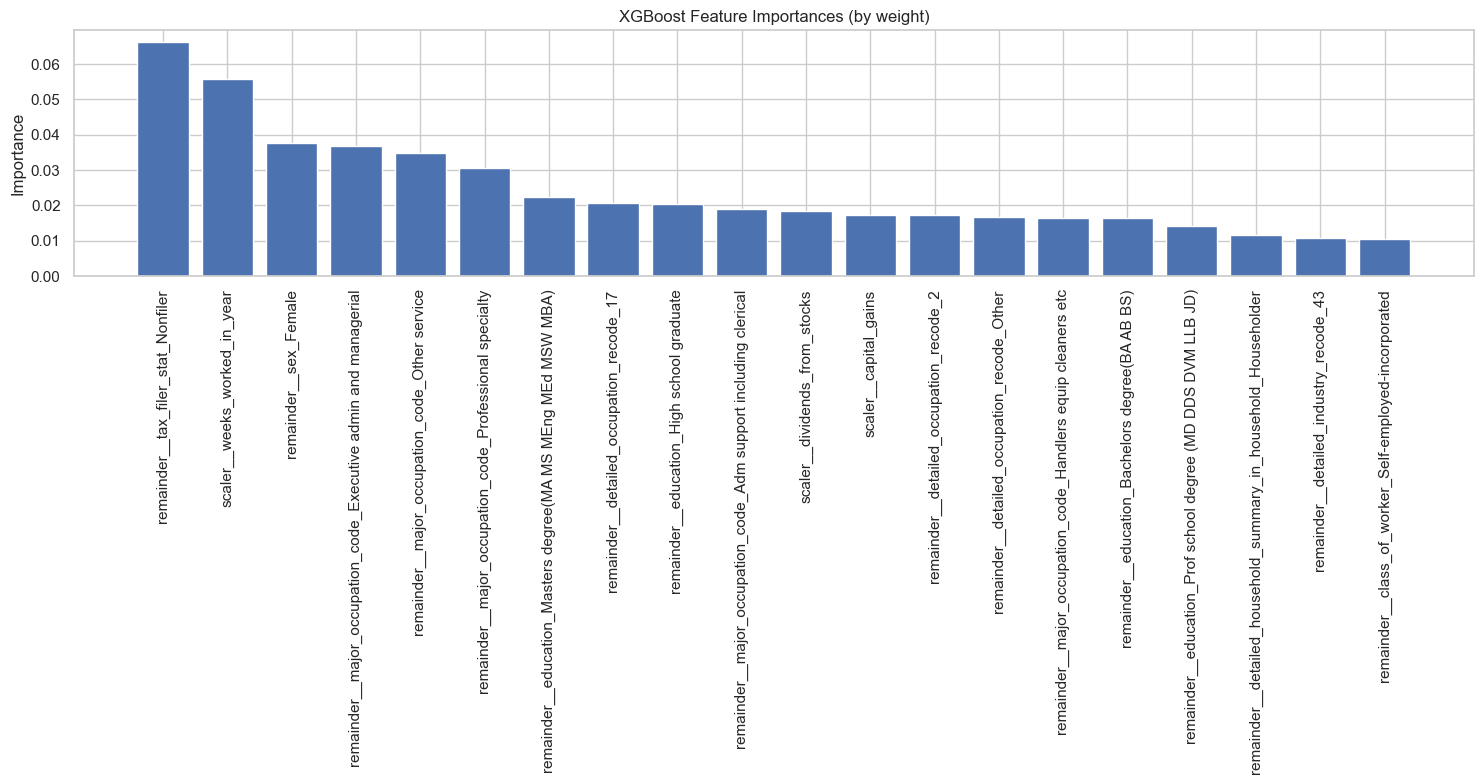

In [51]:
transformer = xgb_spw["transform"]
xgb_model   = xgb_spw["xgb"]   


feature_names = transformer.get_feature_names_out()

importances = xgb_model.feature_importances_

feat_imp_pairs = list(zip(feature_names, importances))
feat_imp_pairs.sort(key=lambda x: x[1], reverse=True)

sorted_features, sorted_values = zip(*feat_imp_pairs)

plt.figure(figsize=(15, 8))
plt.bar(range(len(sorted_features[:20])), sorted_values[:20])
plt.xticks(range(len(sorted_features[:20])), sorted_features[:20], rotation=90)
plt.title("XGBoost Feature Importances (by weight)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

### Feature importance analysis

Because we applied balancing in XGBoost, the model places extra importance on not missing true positives. This drives it to find strong, early splits that best separate higher earners from the rest. If a single categorical or numeric feature can quickly make out a distinct portion of the >=50K group, it becomes heavily used across many decision-tree splits

- Tax filer `Non-filer` appears on top. It can be that filing status signals certain financial or occupational patterns. If people who do not file taxes are predominantly lower-income, the model leverages that distinction
- The number of weeks worked per year remains very high on the list. People working 50+ weeks are more likely to surpass 50K. By placing it near the top, XGBoost is frequently splitting on how many weeks people worked
- Occupation is confirmed to be a big determinant of income. The model invests many splits in occupation categories (like “Executive admin” or “Other service”) because each category lumps together a large chunk of people with a certain pay range
- The same can be said for education as well
- The data analysis did show a wage gaps, so the model might find “Female” splits beneficial to help improve performance. Overall demographic data seems to be beneficial, as evidenced with the inclusion of household features in the top 20 most important


### Performance on test set for best ML model vs heuristic

In [30]:
acc_h, prec_h, rec_h, f1_h, auc_h = evaluate_heuristic(test_df, target_col="high_income")
print("\n=== HEURISTIC BASELINE  (TEST) ===")
print(f"  Accuracy:  {acc_h:.4f}")
print(f"  Precision: {prec_h:.4f}")
print(f"  Recall:    {rec_h:.4f}")
print(f"  F1 Score:  {f1_h:.4f}")
print(f"  ROC AUC:   {auc_h:.4f}")


=== HEURISTIC BASELINE  (TEST) ===
  Accuracy:  0.7976
  Precision: 0.2434
  Recall:    0.7561
  F1 Score:  0.3682
  ROC AUC:   0.7786


In [52]:
final_test_evaluation(xgb_spw, X_test, y_test)


*** TEST SET EVALUATION ***
  Accuracy:  0.8769
  Precision: 0.3734
  Recall:    0.8533
  F1 Score:  0.5195
  ROC AUC:   0.9426


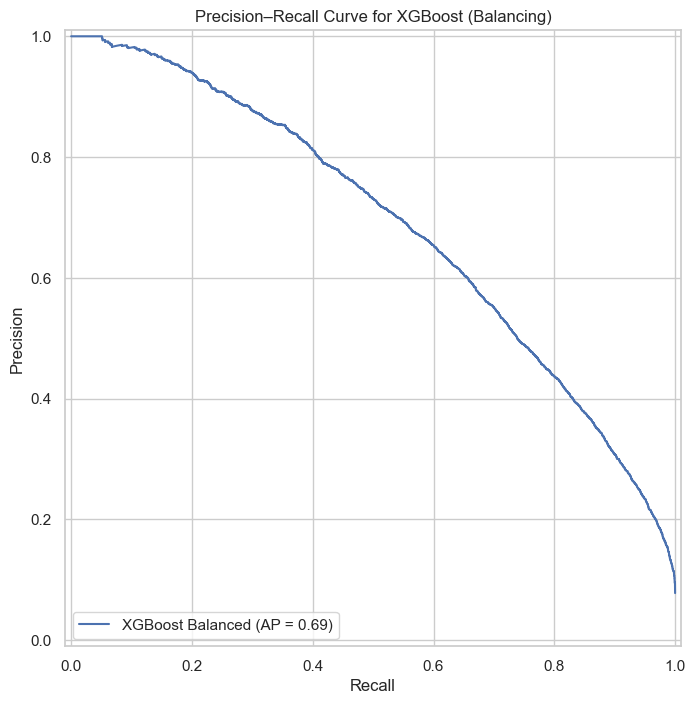

In [55]:
from sklearn.metrics import PrecisionRecallDisplay


PrecisionRecallDisplay.from_estimator(
    estimator=xgb_spw,   
    X=X_test,
    y=y_test,
    name="XGBoost Balanced"
)


plt.title("Precision–Recall Curve for XGBoost (Balancing)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

### Interpretation of results on test set

- The cross-validation metrics reflect how the model does on subsets of the training data. If they align closely with the final test set performance, it means our training/validation approach is accurate in predicting real-world performance
- The near match between CV and test metrics implies the model’s performance claims are credible
- ML model comprehensively beats the rule-based heuristic model
- The heuristic is easy to explain (like “if gains > 0 or working 50 weeks + advanced education => predict high income”), but it creates a flood of incorrect positives
- By penalizing missed positives more heavily, the model invests in occupation, education, tax-filer status, etc., to refine who’s actually high income. The result is a bigger jump in accuracy, precision, recall, and overall F1, making it clearly superior as a production or policy tool
- The improved recall means the model is less likely to pass over an actual >$50K earner
- With higher precision, we reduce the overhead of investigating incorrectly flagged high income individuals
- Precision-Recall curve:
    - On the left side of the plot,precision is near 1.0. That means if we set a high probability threshold, the model becomes extremely selective
    - As we move right along the recall axis (catching more and more actual positives), precision steadily drops. This is expected as more aggressively we label positives, the more false positives we accumulate
    - AP is the area under the precision–recall curve, akin to how ROC AUC measures the area under the ROC curve. An AP of 0.69 indicates the model is fairly strong in balancing precision and recall across all potential thresholds
    - This curve allows policy makers to pick a “comfort zone” of recall vs. precision

### Simple simulation of running inference with the trained model

Pick the best XGBoost model with balancing on recall (arbitrary) and try to run inference on some unseen data. For the purposes of this demonstration, I pick the first 10 data points of the test set. 

In [23]:
from mlflow.tracking import MlflowClient

In [53]:
runs_df = mlflow.search_runs(
    experiment_ids=None,  
    filter_string="params.model_type='XGBoost' and params.imbalance_handling='scale_pos_weight'",
    order_by=["metrics.recall_mean DESC"], 
    max_results=10
)

# If no runs match, runs_df might be empty
if runs_df.empty:
    raise ValueError("No runs found.")


best_run = runs_df.iloc[0]
run_id   = best_run["run_id"]
print("Selected run_id:", run_id)
print("Matching run info:\n", best_run)


Selected run_id: db65410a6c1a4907832b46d4dae63bbd
Matching run info:
 run_id                                            db65410a6c1a4907832b46d4dae63bbd
experiment_id                                                                    0
status                                                                    FINISHED
artifact_uri                     file:///Users/xite/Downloads/Dataiku%20Data%20...
start_time                                        2025-04-13 12:42:28.101000+00:00
end_time                                          2025-04-13 12:42:37.463000+00:00
metrics.precision_mean                                                    0.371772
metrics.recall_mean                                                       0.841693
metrics.accuracy_mean                                                     0.872514
metrics.roc_auc_mean                                                      0.937236
metrics.f1_mean                                                           0.515735
params.model_type

In [54]:
model_uri = f"runs:/{run_id}/XGBoost_cv_pipeline"
inference_pipeline = mlflow.sklearn.load_model(model_uri)


inference_df_tr = transform_dataset(test_df.iloc[0:10].copy(), categorical_columns, reference_columns=train_columns)
X_inference = inference_df_tr.drop(columns=["income", "high_income"], errors="ignore")

pred_classes = xgb_no_balance.predict(X_inference)
pred_probs = xgb_no_balance.predict_proba(X_inference)[:, 1]

for i, row in X_inference.iterrows():
    print(f"Row {i} -> predicted class: {pred_classes[i]}, prob of >=50K: {pred_probs[i]:.3f}")

Row 0 -> predicted class: 0, prob of >=50K: 0.001
Row 1 -> predicted class: 0, prob of >=50K: 0.030
Row 2 -> predicted class: 0, prob of >=50K: 0.000
Row 3 -> predicted class: 0, prob of >=50K: 0.031
Row 4 -> predicted class: 0, prob of >=50K: 0.082
Row 5 -> predicted class: 0, prob of >=50K: 0.000
Row 6 -> predicted class: 0, prob of >=50K: 0.000
Row 7 -> predicted class: 0, prob of >=50K: 0.006
Row 8 -> predicted class: 0, prob of >=50K: 0.093
Row 9 -> predicted class: 0, prob of >=50K: 0.000


/Users/xite/Downloads/Dataiku Data Scientist Technical Assessment/transformations.py:91: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = 0
/Users/xite/Downloads/Dataiku Data Scientist Technical Assessment/transformations.py:91: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = 0
/Users/xite/Downloads/Dataiku Data Scientist Technical Assessment/transformations.py:91: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Cons

### Future Work

- Hyperparameter tuning
    - Spend more time determining the best possible hyparameters
- Imbalance
    - Different ways of considering class imbalance (SMOTE etc.)
- Different encodings
    - Current feature encodings might not encapsulate the full meaning of features
    - Especially if we were to try deep learning approaches
- Fairness / Bias Consideration
    - Sex, or marital status can reflect social biases
    - How do we ensure  we’re not amplifying them
- Handling “Not in Universe”
    - Right now it’s a separate category
    - We might refine subgroups (like children vs. retirees) if we want more nuanced predictions
    - Possibly a separate “universe segmentation,” then model each universe differently.
- Deployment
    - If we require real-time predictions, we’d containerize the pipeline (Docker) or serve it in a microservice
    - If offline, a batch job might be simpler.





